# 투빅스 25&26기 5주차 정규세션 1교시 Computer Vision 과제
---

## Imagenette로 직접 구현하는 ResNet-18 & Vision Transformer

안녕하세요 여러분? 정규세션 CV 파트 담당하게된 정상현입니다. 다들 5주차 정규세션 정말 수고 많으셨습니다. 과제도 열심히 준비했으니, 여러분께 도움이 될 수 있길 바랍니다.

이번 과제에서는 아래의 실습을 해보려합니다

1. **ResNet-18을 직접 구현**하며 Residual Block과 Skip Connection을 코드로 확인합니다.
2. **Vision Transformer(ViT)를 직접 구현**하며 Patch Embedding, CLS Token, Positional Embedding, Transformer Encoder가 실제 코드에서 어떻게 연결되는지 확인합니다.
3. 두 모델을 동일한 조건에서 학습하고 성능과 학습 특성을 비교합니다.
4. 마지막으로 학습 데이터의 양을 바꿔보며, CNN과 ViT의 데이터 효율 차이를 관찰합니다.

이번 과제의 목적은 단순히 “어느 모델의 정확도가 더 높은가?”를 확인하는 것이 아닙니다.  
강의에서 배운 내용들이 실제 학습 결과에서 어떻게 나타나는지 본인의 출력값을 근거로 설명해보는 것이 핵심입니다.

###GPU 사용을 권장합니다. Colab에서는 `런타임 → 런타임 유형 변경 → T4 GPU`를 선택해주세요.



## 제출물

1. 빈칸을 모두 채우고 전부 실행한 노트북 (출력 포함)
2. 기술블로그 '과제 복습' 섹션에 Q.6.2의 실험 결과 및 모델 비교에 대한 본인의 답변을 옮겨 적기


---

## 0. 환경 설정 — Library, Seed, Device

먼저 필요한 라이브러리를 불러오고 실험 환경을 고정해봅시다.

딥러닝 실험에는 가중치 초기화, 데이터 셔플, 데이터 분할 등 여러 곳에서 난수가 사용됩니다.  
따라서 같은 조건을 다시 실행했을 때 최대한 비슷한 결과를 얻을 수 있도록 Seed를 고정합니다.

또한 이미지 모델 학습은 CPU에서 매우 느리므로 GPU가 연결되어 있는지도 함께 확인해봅시다.

**코드의 빈칸을 채워주세요!**

In [1]:
# ── 기본 라이브러리 ─────────────────────────────────────────────
import os
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive

from sklearn.model_selection import train_test_split

# ── 0. 실험 재현성을 위한 Seed 설정 ─────────────────────────────
MY_SEED = 2526            # TODO : 본인이 원하는 시드를 입력하세요!

random.seed(MY_SEED)         # TODO
np.random.seed(MY_SEED)      # TODO
torch.manual_seed(MY_SEED)   # TODO

# GPU가 있으면 CUDA를, 없으면 CPU를 사용합니다.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CUDA 환경에서도 가능한 범위에서 재현성을 높입니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

print("PyTorch version :", torch.__version__)
print("Device          :", DEVICE)
print("Seed            :", MY_SEED)

if DEVICE.type == "cpu":
    print("\n[주의] 현재 CPU 런타임입니다. 전체 학습은 매우 오래 걸릴 수 있습니다.")

PyTorch version : 2.11.0+cu128
Device          : cuda
Seed            : 2526


---
# 1. Imagenette 데이터 준비

## 1.1 Dataset 다운로드 및 확인

이번 과제에서는 **Imagenette 320px** 버전을 사용합니다. Imagenette는 ImageNet에서 10개 클래스를 추려 만든 이미지 분류 데이터셋입니다.

전체 ImageNet을 직접 학습하기에는 계산량이 너무 크기 때문에, 자연 이미지의 특성은 유지하면서도 비교적 가볍게 실험할 수 있는 Imagenette를 사용합니다.

아래 코드는 약 340MB의 압축 파일을 내려받고 `/content/data` 아래에 자동으로 압축을 해제합니다.  
이미 다운로드되어 있다면 다시 받지 않습니다.

**코드 채우기 없습니다!**

In [2]:
# ── Imagenette 다운로드 ──────────────────────────────────────────
DATA_ROOT = Path("/content/data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"
IMAGENETTE_DIR = DATA_ROOT / "imagenette2-320"

if not IMAGENETTE_DIR.exists():
    print("Imagenette를 다운로드합니다...")
    download_and_extract_archive(
        url=IMAGENETTE_URL,
        download_root=str(DATA_ROOT),
        remove_finished=True,
    )
else:
    print("이미 다운로드된 Imagenette를 사용합니다.")

TRAIN_DIR = IMAGENETTE_DIR / "train"
TEST_DIR  = IMAGENETTE_DIR / "val"   # 공식 validation split은 이번 과제에서 최종 test로 사용합니다.

print("Train directory :", TRAIN_DIR)
print("Test directory  :", TEST_DIR)

Imagenette를 다운로드합니다...


100%|██████████| 342M/342M [00:09<00:00, 35.3MB/s]


Train directory : /content/data/imagenette2-320/train
Test directory  : /content/data/imagenette2-320/val


In [3]:
# ── Dataset의 기본 정보 확인 ────────────────────────────────────
# transform을 적용하지 않은 ImageFolder를 먼저 만들어
# 이미지 개수, 클래스, 라벨 분포만 확인합니다.
raw_train = datasets.ImageFolder(TRAIN_DIR)
raw_test  = datasets.ImageFolder(TEST_DIR)

# Imagenette의 폴더명은 ImageNet의 WordNet ID(WNID)입니다.
# 사람이 읽기 편하도록 실제 클래스 이름으로 매핑합니다.
WNID_TO_NAME = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

CLASS_NAMES = [WNID_TO_NAME[c] for c in raw_train.classes]
NUM_CLASSES = len(CLASS_NAMES)

print("Train images :", len(raw_train))
print("Test images  :", len(raw_test))
print("Num classes  :", NUM_CLASSES)
print("Classes      :", CLASS_NAMES)

# 클래스별 샘플 수를 확인합니다.
train_targets = np.array(raw_train.targets)
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

print("\n[Train class distribution]")
for i, count in enumerate(class_counts):
    print(f"{i:2d}. {CLASS_NAMES[i]:18s} : {count}")

Train images : 9469
Test images  : 3925
Num classes  : 10
Classes      : ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']

[Train class distribution]
 0. tench              : 963
 1. English springer   : 955
 2. cassette player    : 993
 3. chain saw          : 858
 4. church             : 941
 5. French horn        : 956
 6. garbage truck      : 961
 7. gas pump           : 931
 8. golf ball          : 951
 9. parachute          : 960


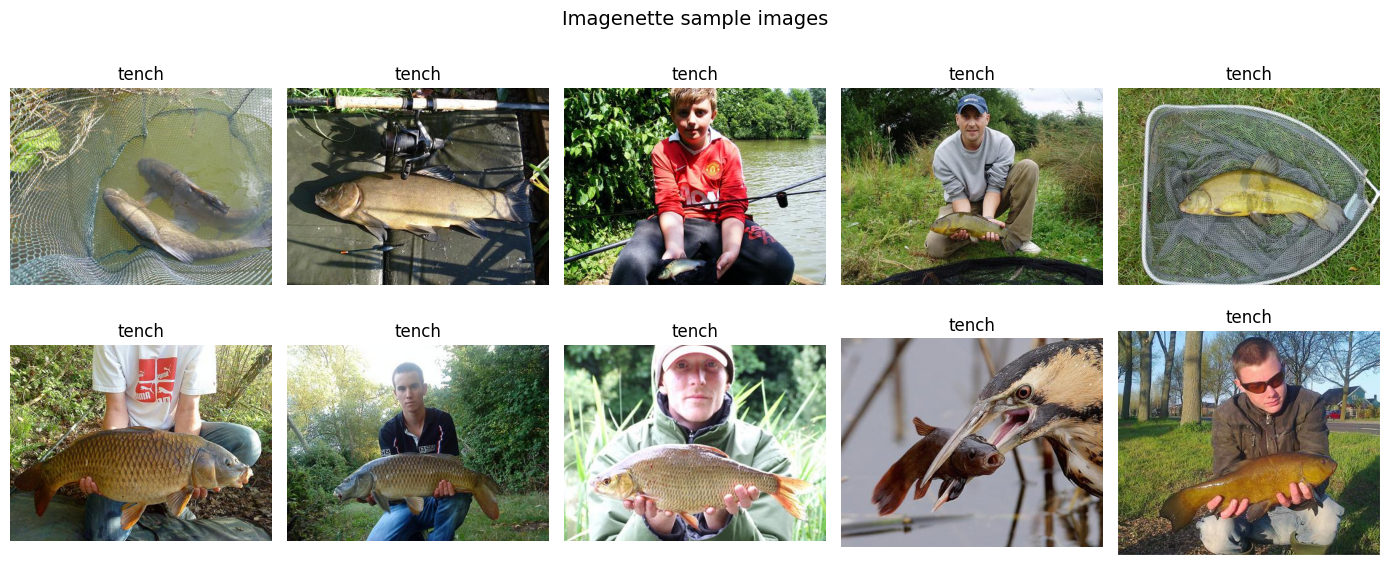

In [4]:
# ── 원본 이미지 직접 확인 ──────────────────────────────────────
# 모델을 학습하기 전에 실제 데이터가 어떻게 생겼는지 먼저 눈으로 확인해봅시다.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.ravel()):
    image, label = raw_train[i]
    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label])
    ax.axis("off")

plt.suptitle("Imagenette sample images", fontsize=14)
plt.tight_layout()
plt.show()

###Q.1.1 데이터 살피기
1.  Train/Test에는 각각 몇장의 이미지가 들어있나요?

    A. Train **9,469장**, Test(공식 val 폴더) **3,925장**이다. 이 9,469장을 다시 8:2로 쪼개기 때문에 실제로 weight 업데이트에 쓰이는 이미지는 7,575장, validation은 1,894장이 된다. 클래스 10개에 대해 완전히 균등하지는 않고 클래스별로 차이가 있다.

2. 원본 이미지들의 가로·세로 크기는 모두 동일해 보이나요?

    A. 동일하지 않다. Imagenette 320px 버전은 **짧은 변**만 320으로 맞춰 리사이즈한 것이라 긴 변의 길이는 원본 종횡비에 따라 제각각이다. 출력된 샘플 이미지들도 어떤 것은 가로로 길고 어떤 것은 세로로 길다. 그래서 다음 단계에서 Crop이나 Resize로 크기를 강제로 통일해주는 과정이 필요하다.

---
## 1.2 Train / Validation / Test 분리와 Image Transform

Imagenette에는 기본적으로 `train`과 `val` 폴더가 있습니다.

이번 과제에서는 다음과 같이 사용합니다.

- **Train**: 모델의 Weight를 실제로 업데이트하는 데이터
- **Validation**: 학습 중 모델을 비교하고 Best Epoch를 선택하는 데이터
- **Test**: 모든 비교가 끝난 뒤 최종 성능을 확인하는 데이터

따라서 원래 Imagenette의 `train`을 다시 **Train 80% / Validation 20%**로 나누고, 공식 `val` 폴더는 마지막 **Test set**으로 남겨두겠습니다.

또한 모델에 입력되는 이미지 크기는 `224 × 224`로 통일합니다.

Train에는 Random Crop과 Horizontal Flip을 적용하지만, Validation/Test에는 무작위 Augmentation을 사용하지 않습니다.  
평가할 때마다 이미지가 달라지면 모델 간 성능 비교 자체가 흔들릴 수 있기 때문입니다.



---
추가로 발표에서 정규화에 대해 다루지 않았기에 짧게 설명을 추가하겠습니다

Image Normalization

이미지의 Pixel 값은 모델에 입력하기 전 일정한 분포를 갖도록 정규화(Normalization) 할 수 있습니다.

각 Channel의 Pixel 값에 대해 다음과 같이 변환합니다.

$$ x_{\text{norm}} = \frac{x-\mu}{\sigma} $$
$\mu$ : 해당 Channel의 평균(Mean)

$\sigma$ : 해당 Channel의 표준편차(Standard Deviation)

RGB 이미지이므로 R, G, B Channel별로 각각 정규화합니다.

이번 과제에서는 ImageNet 계열에서 일반적으로 사용하는 Mean과 Std를 사용합니다.

**코드의 빈칸을 채워주세요!**

In [5]:
# ── ImageNet 계열에서 널리 사용하는 Normalize 값 ──────────────
IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Train에서는 매 epoch마다 조금씩 다른 이미지를 보도록 Data Augmentation을 적용합니다.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),   #TODO : 이미지 크기
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),      #TODO : 정규화!
])

# Validation / Test는 항상 동일한 방식으로 평가합니다.
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),                      #TODO : 이미지 크기
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),      #TODO : 정규화!
])

# 같은 원본 폴더를 사용하지만,
# Train용 Dataset에는 augmentation을, Validation용 Dataset에는 deterministic transform을 적용합니다.
train_aug_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
train_eval_dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

# 원본 Train을 80:20으로 나눕니다.
# stratify를 사용해 Train/Validation의 클래스 비율을 비슷하게 유지합니다.
all_indices = np.arange(len(raw_train))

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=MY_SEED,
    stratify=train_targets,
)

print("Internal train :", len(train_indices))
print("Internal val   :", len(val_indices))
print("Final test     :", len(test_dataset))

Internal train : 7575
Internal val   : 1894
Final test     : 3925


In [6]:
# ── DataLoader 생성 ─────────────────────────────────────────────
BATCH_SIZE = 64
NUM_WORKERS = 2

train_dataset = Subset(train_aug_dataset, train_indices)
val_dataset   = Subset(train_eval_dataset, val_indices)

# DataLoader의 shuffle 순서도 Seed를 고정합니다.
train_generator = torch.Generator().manual_seed(MY_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    generator=train_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

# 한 Mini-batch의 Tensor Shape를 확인합니다.
images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Label example     :", labels[:10].tolist())

Image batch shape : torch.Size([64, 3, 224, 224])
Label batch shape : torch.Size([64])
Label example     : [8, 1, 3, 0, 3, 8, 4, 0, 8, 4]


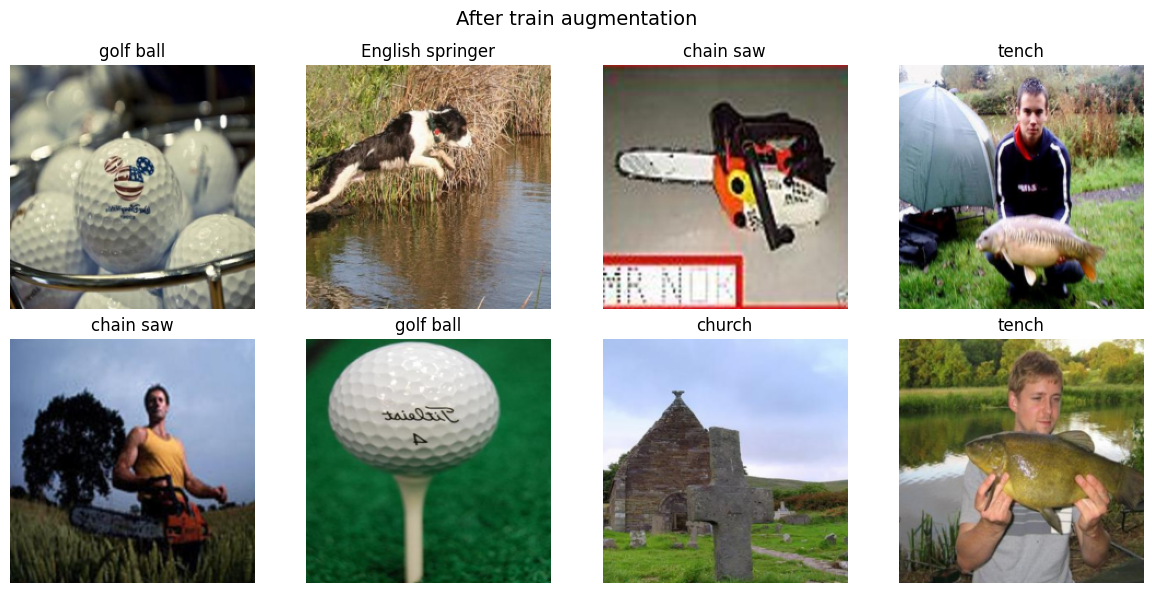

In [7]:
# ── Normalize된 이미지를 다시 화면에 표시하는 함수 ────────────
def denormalize(img_tensor):
    """Normalize된 (C,H,W) Tensor를 시각화 가능한 [0,1] 범위로 되돌립니다."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1)

# 실제 Train transform이 적용된 이미지도 확인해봅시다.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.ravel()):
    img = denormalize(images[i]).permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis("off")

plt.suptitle("After train augmentation", fontsize=14)
plt.tight_layout()
plt.show()

###Q.1.2 이미지의 전처리와 데이터 분할을 생각해봅시다

1. `images.shape`를 실제 출력값 그대로 적고, 각 차원이 무엇을 의미하는지 설명해주세요.

    A. `torch.Size([64, 3, 224, 224])` 이다. 앞에서부터 (Batch Size, Channel, Height, Width)를 뜻한다. 64는 `BATCH_SIZE`로 한 번에 묶어 넣는 이미지 수, 3은 RGB 채널, 뒤의 224 두 개가 `IMAGE_SIZE`로 맞춰진 세로·가로 픽셀 수다. PyTorch는 채널이 앞에 오는 NCHW 순서를 쓰기 때문에 `matplotlib`으로 그릴 때는 `permute(1, 2, 0)`으로 HWC로 바꿔줘야 한다.

2. 이미지의 입력 크기를 동일하게 맞춰야하는 이유에 대해 설명해주세요.

    A. 크게 두 가지다. 첫째, Mini-batch는 결국 하나의 4차원 Tensor라서 안에 들어가는 이미지의 H, W가 다르면 애초에 쌓을 수가 없다. 둘째, 모델 쪽에도 고정 크기를 전제로 하는 부분이 있다. ViT는 Positional Embedding의 길이가 Patch 개수에 맞춰 미리 정해지므로 입력 크기가 달라지면 길이가 안 맞고, ResNet도 Global Average Pooling 덕분에 비교적 자유롭긴 하지만 크기가 제각각이면 배치 자체가 불가능하다.

3. Train Set에서 Crop, Random Flip 하는 이유에 대해 설명해주세요.

    A. Data Augmentation으로 과적합을 줄이기 위해서다. 같은 이미지라도 매 epoch마다 조금씩 다르게 잘리고 뒤집히므로 모델 입장에서는 데이터가 늘어난 효과가 난다. 더 중요한 건 모델이 배우는 내용이 달라진다는 점이다. `RandomResizedCrop(scale=(0.7, 1.0))`은 대상이 이미지의 어느 위치에 어떤 크기로 있든 같은 클래스임을 학습하게 만들고, Horizontal Flip은 좌우 반전에 대한 불변성을 준다. 7,575장은 밑바닥부터 학습시키기에 적은 양이라 augmentation 없이는 train accuracy만 빠르게 올라가고 validation은 따라오지 않는다.

4. Val Set에서도 Train Set과 동일한 Augmentation을 적용하나요? 이유와 함께 설명해주세요.

    A. 적용하지 않는다. Validation은 성능을 **재는** 용도인데 평가할 때마다 이미지가 무작위로 달라지면 측정값 자체에 노이즈가 섞인다. 그러면 val accuracy가 올라간 것이 모델이 좋아져서인지 그 epoch에 우연히 쉬운 crop이 걸려서인지 구분할 수 없고, Best Epoch를 고르는 기준도 흔들린다. 그래서 `eval_transform`은 `Resize(256)` → `CenterCrop(224)`처럼 항상 같은 결과를 내는 deterministic 변환만 쓴다. 다만 Normalize는 성능 측정을 방해하는 무작위성이 아니라 입력 분포를 맞추는 처리이므로 Train과 똑같이 적용해야 한다.

---

# 2. 공통 Training Pipeline 만들기

이제 ResNet과 ViT가 공통으로 사용할 학습 함수를 준비해봅시다.

두 모델은 구조는 다르지만, 학습 과정 자체는 동일합니다.

> `Mini-batch → Forward → Loss → Backward → Weight Update`

이번 비교에서는 두 모델 모두 같은 `CrossEntropyLoss`, `AdamW`, `CosineAnnealingLR`을 사용합니다.  
즉, 모든 모델에 가장 최적인 Hyperparameter를 찾는 것이 아니라 **가능한 한 동일한 학습 조건에서 구조적 차이를 관찰**하는 것이 목적입니다.

또한 Validation Accuracy가 가장 높았던 시점의 Weight를 저장하고, 학습이 끝난 뒤 그 Weight를 다시 불러옵니다.  
Test set은 아직 사용하지 않습니다.

**공통 코드기 때문에 따로 코드 빈칸 채우기는 없습니다!**

In [8]:
# ── 공통 Loss Function ──────────────────────────────────────────
# CrossEntropyLoss 내부에서 LogSoftmax가 처리되므로
# 모델 마지막에 Softmax를 직접 붙이지 않습니다.
criterion = nn.CrossEntropyLoss()


def count_parameters(model):
    """학습 가능한 Parameter의 총 개수를 반환합니다."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, optimizer, device):
    """한 epoch 동안 Train set으로 Weight를 업데이트합니다."""
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # 이전 Mini-batch에서 계산된 Gradient를 초기화합니다.
        optimizer.zero_grad()

        # Forward: 현재 Weight로 Class Logit을 예측합니다.
        logits = model(images)

        # 정답 Label과 비교하여 Loss를 계산합니다.
        loss = criterion(logits, labels)

        # Backward: 각 Parameter에 대한 Gradient를 계산합니다.
        loss.backward()

        # 계산된 Gradient를 이용해 Parameter를 업데이트합니다.
        optimizer.step()

        # Epoch 전체의 평균 Loss/Accuracy를 계산하기 위해 누적합니다.
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, device):
    """Validation/Test set에서는 Gradient를 계산하지 않고 Loss와 Accuracy만 측정합니다."""
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [9]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=3e-4,
    weight_decay=0.05,
    model_name="model",
):
    """
    하나의 모델을 학습하고 History와 요약 정보를 반환합니다.

    - Optimizer: AdamW
    - Scheduler: CosineAnnealingLR
    - Best Validation Accuracy가 갱신될 때 Weight를 저장
    - 학습 종료 후 Best Weight를 복원
    """
    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    best_val_acc = -1.0
    best_epoch = -1
    best_state = None

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, DEVICE
        )

        val_loss, val_acc = evaluate(
            model, val_loader, DEVICE
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Validation Accuracy가 가장 높았던 모델을 저장합니다.
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        scheduler.step()

        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
            f"lr {current_lr:.2e}"
        )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start_time

    # 가장 좋은 Validation Accuracy를 기록했던 Weight로 되돌립니다.
    model.load_state_dict(best_state)

    summary = {
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "total_time_sec": elapsed,
        "sec_per_epoch": elapsed / epochs,
    }

    print(
        f"\n[{model_name}] Best val acc = {best_val_acc:.4f} "
        f"(epoch {best_epoch}) | "
        f"total time = {elapsed/60:.1f} min"
    )

    return model, history, summary


def plot_history(history, title):
    """Train/Validation의 Loss와 Accuracy 학습 곡선을 출력합니다."""
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs, history["train_acc"], label="train")
    plt.plot(epochs, history["val_acc"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

---
# 3. ResNet-18 직접 구현하기

이제 첫 번째 모델인 **ResNet-18**을 직접 구현해봅시다.

ResNet의 핵심은 전체 `H(x)`를 직접 학습하기보다 Residual Function `F(x)`를 학습하도록 만드는 것입니다.

Basic Residual Block은 다음과 같은 구조를 가집니다.

- Main Path: `Conv → BN → ReLU → Conv → BN`
- Shortcut Path: 입력 `x`를 그대로 전달
- 두 경로를 **Element-wise Addition**
- 마지막 ReLU

즉, Block의 핵심은 다음과 같습니다.

\[
y = F(x) + x
\]

다만 Feature Map의 Channel 수나 Spatial Size가 달라지는 지점에서는 `x`와 `F(x)`의 Shape가 달라 단순 Addition이 불가능합니다.  
이 경우 Shortcut Path에 **1×1 Convolution**을 사용해 Shape을 맞춥니다.

**코드 빈칸을 채워주세요!**

In [10]:
# ── ResNet BasicBlock ───────────────────────────────────────────
def conv3x3(in_channels, out_channels, stride=1):
    """3x3 Convolution 후 Spatial Size를 제어합니다."""
    return nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size=3,   #TODO : 다 적혀있다!
        stride=stride,
        padding=1,       #TODO : 사이즈를 유지하려면?
        bias=False,
    )


class BasicBlock(nn.Module):
    """
    ResNet-18 / ResNet-34에서 사용하는 Basic Residual Block입니다.

    Main path:
        3x3 Conv -> BN -> ReLU -> 3x3 Conv -> BN

    Shortcut:
        Shape가 같으면 Identity
        Shape가 다르면 1x1 Conv + BN

    마지막에 Main path와 Shortcut을 Addition합니다.
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = conv3x3(
            in_channels,
            out_channels,
            stride=stride,      # TODO: Block의 Downsampling 여부 반영
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = conv3x3(
            out_channels,
            out_channels,
            stride=1,      # TODO: 두 번째 Conv의 Stride
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 입력과 출력의 Shape가 같다면 그대로 전달합니다.
        self.shortcut = nn.Identity()

        # Spatial Size 또는 Channel 수가 달라지면
        # 1x1 Conv를 이용해 Shortcut의 Shape를 Main Path와 맞춥니다.
        if stride != 1 or in_channels != out_channels:   # TODO: 입/출력 사이즈가 다르려면?
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,       # TODO: Projection에 사용할 Kernel
                    stride=stride,            # TODO
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        # Shortcut Path의 입력을 미리 저장합니다.
        identity = self.shortcut(x)

        # Main Path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Residual Connection의 핵심:
        # Feature를 Channel 방향으로 붙이는 것이 아니라 Element-wise Addition합니다.
        out = out + identity         #TODO

        out = self.relu(out)
        return out

In [11]:
# ── ResNet-18 전체 Architecture ─────────────────────────────────
class ResNet18(nn.Module):
    """
    ResNet-18 구조

    Stem:
        7x7 Conv -> BN -> ReLU -> MaxPool

    Residual Stages:
        [2, 2, 2, 2]개의 BasicBlock
        Channel: 64 -> 128 -> 256 -> 512

    Head:
        Global Average Pooling -> Fully Connected
    """

    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        # ── Stem ────────────────────────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1,
            ),
        )

        # ── Residual Stages ─────────────────────────────────────
        self.layer1 = self._make_layer(
            out_channels=64,
            blocks=2,
            stride=1,
        )

        self.layer2 = self._make_layer(
            out_channels=128,
            blocks=2,
            stride=2,
        )

        self.layer3 = self._make_layer(
            out_channels=256,
            blocks=2,
            stride=2,
        )

        self.layer4 = self._make_layer(
            out_channels=512,
            blocks=2,
            stride=2,
        )

        # 입력 이미지 크기와 관계없이 (1,1)로 평균 Pooling합니다.
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Imagenette는 10개 Class이므로 Output Dimension은 10입니다.
        self.fc = nn.Linear(512, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, blocks, stride):
        """
        하나의 ResNet Stage를 구성합니다.

        첫 Block:
            필요하면 stride=2로 Downsampling
            Channel도 변경

        나머지 Block:
            stride=1로 같은 Shape 유지
        """
        layers = []

        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride,
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1,
                )
            )

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        """Convolution과 BatchNorm의 초기 Weight를 설정합니다."""
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu",
                )

            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        # (B, 512, 1, 1) -> (B, 512)
        x = torch.flatten(x, 1)      # TODO

        logits = self.fc(x)     # TODO
        return logits

In [12]:
# ── ResNet-18 구조가 정상적으로 동작하는지 학습 전에 확인 ───────
torch.manual_seed(MY_SEED)

resnet18 = ResNet18(num_classes=NUM_CLASSES)

# 실제 학습 전에 가짜 입력으로 Forward Shape를 먼저 확인합니다.
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    dummy_output = resnet18(dummy)

print(resnet18)
print("\nResNet-18 output shape :", dummy_output.shape)
print("Trainable parameters  :", f"{count_parameters(resnet18):,}")

# Classifier이므로 Output Shape는 (Batch Size, Num Classes)가 되어야 합니다.
assert dummy_output.shape == (2, NUM_CLASSES)

ResNet18(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runni

###Q.3.1 ResNet 구조를 코드와 연결해봅시다.

1. 직접 구현한 ResNet-18의 학습 가능한 Parameter 수는 몇 개인가요?

    A. 11,181,642개다. 대부분이 `layer4`에 몰려 있는데, 채널이 512로 가장 크고 3×3 Conv 하나가 512×512×9 ≈ 236만 개를 쓰기 때문이다. 반대로 마지막 `fc`는 512×10 + 10 = 5,130개로 전체의 0.05%도 안 된다.


2. `BasicBlock`에서 Main Path의 출력과 입력 `x`를 **Concatenation이 아니라 Addition**으로 결합합니다. Addition을 하기 위해 두 Tensor가 만족해야 하는 Shape 조건은 무엇인가요?

    A. Channel 수와 Spatial Size가 모두 같아야 한다. 즉 (C, H, W)가 완전히 일치해야 element-wise addition이 성립한다. Concatenation은 이어붙일 축만 빼고 나머지가 같으면 되지만 Addition은 그런 여유가 없다. 대신 Concat은 채널 수가 계속 늘어나 다음 Conv의 파라미터도 같이 불어나는 반면, Addition은 채널 수를 그대로 유지하면서 `y = F(x) + x` 라는 잔차 형태를 만들 수 있다.


3. `layer2`, `layer3`, `layer4`의 첫 번째 Block에서는 왜 Shortcut에도 `1×1 Conv`가 필요한가요?

    A. 이 세 Stage의 첫 Block에서는 두 가지가 동시에 바뀌기 때문이다. `stride=2`라서 Spatial Size가 절반이 되고(56→28→14→7), Channel도 2배로 늘어난다(64→128→256→512). 그 결과 Main Path 출력은 예를 들어 (128, 28, 28)인데 입력 `x`는 (64, 56, 56)이라 그대로는 더할 수가 없다. 그래서 Shortcut에 `stride=2`인 1×1 Conv를 걸어 공간 크기를 절반으로 줄이면서 채널도 맞춰준다. 1×1을 쓰는 이유는 공간 정보를 섞지 않고 채널 방향으로만 선형 변환하는, 형태를 맞추기 위한 최소한의 연산이기 때문이다. 반면 `layer1`과 각 Stage의 두 번째 Block은 stride가 1이고 채널도 그대로라 `nn.Identity()`가 그대로 쓰인다.


4. ResNet의 Skip Connection이 깊은 Network의 Optimization을 쉽게 만드는 이유를 **Gradient가 전달되는 경로**의 관점에서 설명해주세요.

    A. 덧셈 노드는 역전파에서 들어온 gradient를 두 갈래로 **그대로 복사해서** 흘려보낸다. 그래서 `y = F(x) + x`를 x에 대해 미분하면 `∂y/∂x = ∂F/∂x + 1` 이 되고, 여기서 상수 1이 핵심이다. Main Path의 `∂F/∂x`가 아무리 작아져도 1이 남아 있으므로 gradient가 0으로 소멸하지 않는다.

    경로의 관점에서 보면, Skip Connection이 없는 일반 네트워크는 입력까지 가는 길이 층을 전부 통과하는 하나뿐이라 각 층의 Jacobian이 계속 곱해지며 크기가 지수적으로 줄거나 커진다. Skip Connection이 있으면 Block을 건너뛰는 지름길이 생겨 앞쪽 층까지 거의 감쇠 없이 도달하는 짧은 경로가 함께 존재하게 된다.

    학습 목표 측면에서도 유리하다. 어떤 Block이 별로 할 일이 없는 상황이라면 `F(x) = 0`만 만들면 항등 함수가 되는데, 이건 가중치를 0 근처로 보내면 되는 쉬운 문제다. Skip이 없다면 같은 일을 하기 위해 여러 층이 협력해서 항등 사상을 정확히 흉내 내야 하고 이게 훨씬 어렵다. 층을 더 쌓았는데 오히려 training error가 올라가던 degradation 문제가 이걸로 해소된 것이다.

---
## 3.2 ResNet-18을 Imagenette 100%로 학습해봅시다.

이제 직접 구현한 ResNet-18을 실제로 학습합니다.

뒤에서 ViT와 같은 조건으로 비교할 것이므로 아래 Hyperparameter는 공통으로 사용하겠습니다.

- Epoch: 20
- Batch Size: 64
- Optimizer: AdamW
- Learning Rate: `3e-4`
- Weight Decay: `0.05`
- Scheduler: Cosine Annealing

> GPU 종류에 따라 학습 시간이 쪼오끔 걸릴 수 있습니다. (저는 20-30분 정도 걸렸습니다)

[ResNet-18 / 100%] Epoch 01/10 | train loss 1.5101 acc 0.4953 | val loss 1.6480 acc 0.4963 | lr 3.00e-04
[ResNet-18 / 100%] Epoch 02/10 | train loss 1.0782 acc 0.6484 | val loss 1.8191 acc 0.4820 | lr 2.93e-04
[ResNet-18 / 100%] Epoch 03/10 | train loss 0.8679 acc 0.7203 | val loss 1.0274 acc 0.6753 | lr 2.71e-04
[ResNet-18 / 100%] Epoch 04/10 | train loss 0.7704 acc 0.7505 | val loss 0.9052 acc 0.7122 | lr 2.38e-04
[ResNet-18 / 100%] Epoch 05/10 | train loss 0.6662 acc 0.7817 | val loss 0.8870 acc 0.7286 | lr 1.96e-04
[ResNet-18 / 100%] Epoch 06/10 | train loss 0.5666 acc 0.8162 | val loss 0.8366 acc 0.7323 | lr 1.50e-04
[ResNet-18 / 100%] Epoch 07/10 | train loss 0.4919 acc 0.8376 | val loss 0.7588 acc 0.7545 | lr 1.04e-04
[ResNet-18 / 100%] Epoch 08/10 | train loss 0.4045 acc 0.8697 | val loss 0.6290 acc 0.8004 | lr 6.18e-05
[ResNet-18 / 100%] Epoch 09/10 | train loss 0.3462 acc 0.8919 | val loss 0.6147 acc 0.8046 | lr 2.86e-05
[ResNet-18 / 100%] Epoch 10/10 | train loss 0.3149 acc 

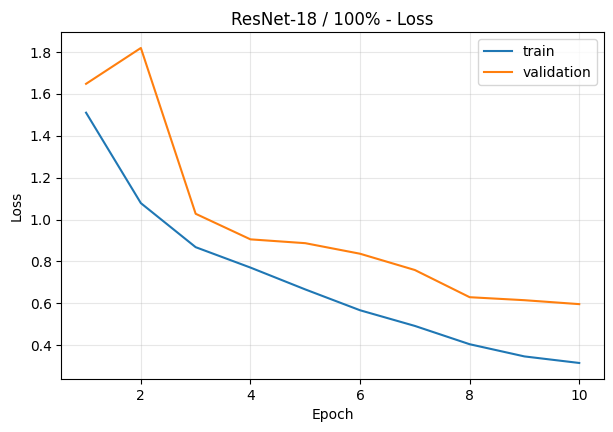

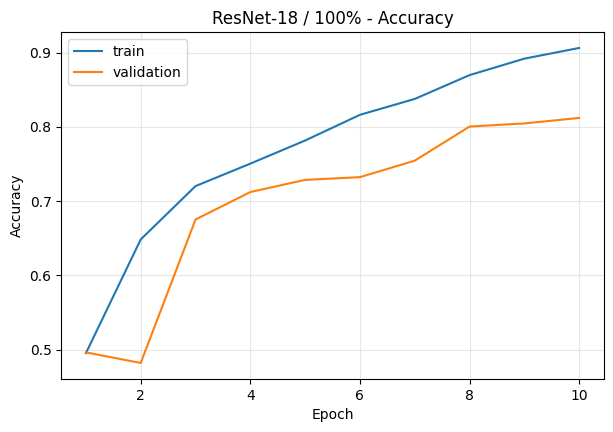

In [13]:
# ── 공통 학습 설정 ──────────────────────────────────────────────
EPOCHS = 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05

# 모델 초기화를 동일하게 재현하기 위해 Seed를 다시 고정합니다.
torch.manual_seed(MY_SEED)

resnet18 = ResNet18(num_classes=NUM_CLASSES)

# ResNet과 ViT가 같은 Seed에서 Shuffle을 시작하도록
# 모델별로 Train DataLoader를 새로 생성합니다.
resnet_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    generator=torch.Generator().manual_seed(MY_SEED),
)

resnet18, hist_resnet_100, summary_resnet_100 = train_model(
    model=resnet18,
    train_loader=resnet_train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    model_name="ResNet-18 / 100%",
)

plot_history(hist_resnet_100, "ResNet-18 / 100%")

### Q.3.2 ResNet 학습 결과를 확인해봅시다.

1. ResNet-18의 Best Validation Accuracy와 해당 Epoch를 적어주세요.

    A. Best Validation Accuracy는 **0.8120**이었고 마지막인 **10번째 epoch**에서 나왔다. 총 학습 시간은 7.6분, epoch당 약 45.6초였다.

    Best Epoch가 마지막이라는 점이 중요하다. 계산 자원 제약으로 20 epoch 대신 10 epoch만 학습시켰는데, val accuracy가 8→9→10에서 0.8004 → 0.8046 → 0.8120으로 계속 오르는 중이었다. 즉 아직 수렴하지 않은 상태에서 epoch 수에 막혀 멈춘 것이고, 더 돌렸다면 조금 더 올라갔을 것으로 보인다.

2. 학습은 안정적인 것 같나요? 그렇게 생각한 이유를 적어주세요.

    A. 후반부는 안정적이었지만 초반에는 꽤 흔들렸다.

    train loss는 1.5101 → 0.3149로 10 epoch 내내 한 번도 반등 없이 단조 감소했다. 이쪽은 깔끔하다. 문제는 validation 쪽이었다. epoch 1에서 val acc 0.4963이었는데 epoch 2에서 0.4820으로 **떨어졌고**, val loss도 1.6480 → 1.8191로 오히려 올랐다. epoch 3부터는 0.6753 → 0.7122 → 0.7286으로 방향을 잡고 꾸준히 올라 마지막까지 한 번도 꺾이지 않았다.

    초반에 튄 이유는 Learning Rate가 아직 3.00e-04로 가장 높은 구간이라 weight가 크게 움직였기 때문으로 보인다. Cosine Annealing으로 lr이 내려가면서(epoch 8에 6.18e-05) 곡선도 같이 안정됐다. 실제로 val loss가 가장 크게 떨어진 것도 epoch 7→8 구간(0.7588 → 0.6290)으로 lr이 충분히 작아진 뒤였다.

    과적합 조짐도 있다. 마지막 epoch에서 train acc 0.9063, val acc 0.8120으로 약 9%p 차이가 벌어졌다. 7,575장으로 1,100만 파라미터 모델을 밑바닥부터 학습시키는 것이니 자연스러운 방향이고, augmentation과 weight decay 0.05가 그걸 눌러 주고 있는 상태로 읽었다. 다만 val loss가 끝까지 내려가고 있었으므로(0.5959) 아직 과적합이 성능을 해치는 단계는 아니었다.

---

# 4. Vision Transformer 직접 구현하기

두 번째 모델은 **Vision Transformer(ViT)** 입니다.

ViT는 이미지를 CNN처럼 작은 Convolution Kernel로 반복 처리하는 대신, 이미지를 일정한 크기의 **Patch**로 나누어 하나의 Token Sequence로 바꾼 뒤 Transformer Encoder에 입력합니다.

이번 과제에서는 Transformer의 Attention 수식 전체를 바닥부터 구현하지는 않습니다.  
PyTorch가 제공하는 `nn.MultiheadAttention`을 사용하되, ViT의 전체 구조는 직접 구성해봅시다.

직접 구현할 요소는 다음과 같습니다.

1. **Patch Embedding**
2. **CLS Token**
3. **Positional Embedding**
4. **Transformer Encoder Block**
5. **MLP Head**

먼저 이미지를 Patch Token으로 바꾸는 과정부터 구현해봅시다.

---
## 4.1 Patch Embedding

입력 이미지 크기가 `224 × 224`, Patch 크기가 `16 × 16`이라면 한 변에 14개의 Patch가 생깁니다.

따라서 전체 Patch 수는

\[
14 x 14 = 196
\]

개입니다.

각 Patch를 직접 잘라서 Flatten할 수도 있지만, `kernel_size = stride = patch_size`인 `Conv2d`를 사용하면 **겹치지 않는 Patch 분할과 Linear Projection을 한 번에 구현**할 수 있습니다.


**코드 빈칸을 채워주세요!**

In [14]:
# ── ViT Patch Embedding ─────────────────────────────────────────
class PatchEmbedding(nn.Module):
    """
    (B, 3, H, W) 이미지를
    (B, N, D) Patch Token Sequence로 변환합니다.

    N = Patch 개수
    D = Embedding Dimension
    """

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        in_channels=3,
        embed_dim=192,
    ):
        super().__init__()

        assert image_size % patch_size == 0, \
            "Image Size는 Patch Size로 나누어 떨어져야 합니다."

        self.image_size = image_size
        self.patch_size = patch_size

        patches_per_side = image_size // patch_size     # TODO
        self.num_patches = patches_per_side ** 2        # TODO

        # kernel_size와 stride를 Patch Size와 같게 설정하면
        # 서로 겹치지 않는 Patch를 만들면서 각 Patch를 embed_dim 차원으로 Projection할 수 있습니다.
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,               # TODO
            stride=patch_size,                    # TODO
        )

    def forward(self, x):
        # 입력: (B, 3, 224, 224)
        x = self.proj(x)

        # 예: (B, 192, 14, 14)
        # Spatial Dimension을 펼쳐 (B, 192, 196)으로 만듭니다.
        x = x.flatten(2)

        # Transformer는 Token Dimension이 두 번째 축에 오도록
        # (B, 196, 192) 형태로 바꿉니다.
        x = x.transpose(1, 2)

        return x

In [15]:
# ── Patch Embedding Shape 확인 ──────────────────────────────────
PATCH_SIZE = 16
EMBED_DIM = 192

patch_embed = PatchEmbedding(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
)

dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    patch_tokens = patch_embed(dummy)

print("Input image shape :", dummy.shape)
print("Patch token shape :", patch_tokens.shape)
print("Number of patches :", patch_embed.num_patches)
print("Embedding dim     :", EMBED_DIM)

Input image shape : torch.Size([2, 3, 224, 224])
Patch token shape : torch.Size([2, 196, 192])
Number of patches : 196
Embedding dim     : 192


### Q.4.1 Patch를 Token으로 바꾸는 과정을 확인해봅시다.

1. 실제 `patch_tokens.shape`를 적고 각 차원이 무엇을 의미하는지 설명해주세요.

    A. `torch.Size([2, 196, 192])` 이다. 2는 Batch Size(확인용 dummy 입력이 2장), 196은 Token 개수, 192는 각 Token의 Embedding Dimension이다. 196은 224를 16으로 나눈 14를 제곱한 값으로, 이미지를 겹치지 않게 16×16으로 자르면 14×14 격자가 나온다는 뜻이다. 원래 (2, 3, 224, 224)였던 이미지가 (2, 196, 192)가 되었으니, 2차원 격자 구조를 버리고 **길이 196짜리 Token Sequence**로 바뀐 셈이다. 이때부터는 NLP의 문장과 형태가 같아져 Transformer Encoder를 그대로 쓸 수 있다.

2. Patch Size를 `32×32`로 키운다면 Token 수는 몇 개로 줄어드나요?

    A. (224 / 32)² = 7² = 49개로 줄어든다. 196개에서 49개이므로 정확히 1/4이다. Patch 한 변이 2배가 되면 한 변의 Patch 수가 절반이 되고, 2차원이니 전체로는 1/4이 된다.

3. Token 수가 줄어들면 Self-Attention의 계산량은 일반적으로 어떤 방향으로 변할까요?

    A. 크게 줄어든다. Self-Attention은 모든 Token 쌍의 유사도를 구하므로 QKᵀ가 N×N 행렬이 되고, 계산량과 메모리가 Token 수 N에 대해 O(N²)로 증가한다. 따라서 N이 1/4이 되면 Attention 부분의 비용은 대략 1/16로 떨어진다.

    다만 공짜는 아니다. Patch가 커진 만큼 한 Token이 담당하는 영역이 넓어져 표현이 거칠어지고, 작은 물체나 세밀한 질감을 구분하기 어려워진다. ViT 논문에서도 같은 모델이라면 Patch Size가 작을수록(ViT-B/16이 ViT-B/32보다) 성능이 좋지만 연산량은 훨씬 크다고 보고한다. 결국 Patch Size는 해상도와 계산량을 맞바꾸는 손잡이다.

---
## 4.2 Transformer Encoder와 ViT 전체 구조

Patch Token만 Transformer에 넣으면 각 Token이 원래 이미지의 어느 위치에서 왔는지 알기 어렵습니다.  
따라서 각 위치에 대응하는 **Positional Embedding**을 더해줍니다.

또한 이미지 전체를 하나의 Class로 분류해야 하므로 Patch Token 앞에 학습 가능한 **CLS Token**을 추가합니다.

결과적으로 Transformer Encoder에 들어가는 Sequence는 다음과 같습니다.

`[CLS] + Patch 1 + Patch 2 + ... + Patch 196`

즉 Sequence Length는 총 **197**입니다.

Encoder Block 내부에서는 다음 두 단계가 반복됩니다.

1. `LayerNorm → Multi-Head Self-Attention → Residual Connection`
2. `LayerNorm → MLP → Residual Connection`

이번 구현에서는 ViT에서 널리 사용되는 **Pre-Norm 구조**를 사용합니다.


**코드 빈칸을 채워주세요!!**

Encoder Block 구현할 때 구조 참고하세요!

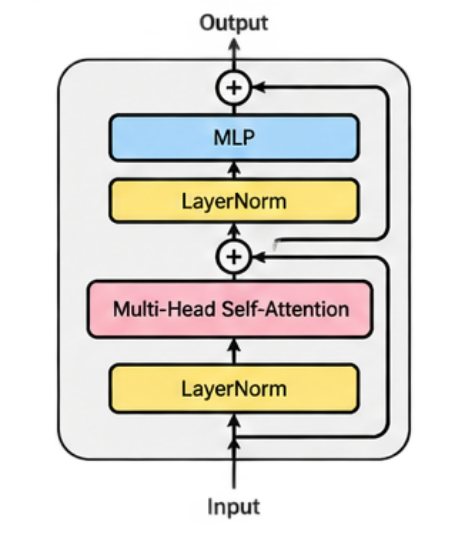

In [16]:
# ── ViT의 MLP Block ─────────────────────────────────────────────
class MLP(nn.Module):
    """Transformer Encoder 안에서 각 Token의 Feature를 변환하는 Feed-Forward Network입니다."""

    def __init__(self, embed_dim, mlp_ratio=4.0, dropout=0.1):
        super().__init__()

        hidden_dim = int(embed_dim * mlp_ratio)

        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


# ── Transformer Encoder Block ───────────────────────────────────
class TransformerEncoderBlock(nn.Module):
    """
    Pre-Norm Transformer Encoder Block

    x = x + MSA(LN(x))
    x = x + MLP(LN(x))
    """

    def __init__(
        self,
        embed_dim,
        num_heads,
        mlp_ratio=4.0,
        dropout=0.1,
        attn_dropout=0.0,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        # batch_first=True이므로 입력 Shape를 (B, N, D)로 그대로 사용할 수 있습니다.
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True,
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = MLP(
            embed_dim=embed_dim,
            mlp_ratio=mlp_ratio,
            dropout=dropout,
        )

    def forward(self, x):
        # ── Multi-Head Self-Attention + Residual ────────────────
        norm_x = self.norm1(x)               # TODO : 첫번째 LayerNorm

        attn_out, _ = self.attn(
            norm_x,                         # TODO
            norm_x,                         # TODO
            norm_x,                         # TODO
            need_weights=False,
        )

        x = x + attn_out                    # TODO

        # ── MLP + Residual ─────────────────────────────────────
        x = x + self.mlp(self.norm2(x))     # TODO

        return x

**여기도 빈칸 많아요**

In [17]:
# ── Vision Transformer 전체 Architecture ────────────────────────
class VisionTransformer(nn.Module):
    """
    교육용 ViT-Tiny 스타일 모델

    Image
      -> Patch Embedding
      -> [CLS] Token 추가
      -> Positional Embedding 추가
      -> Transformer Encoder Blocks
      -> Final LayerNorm
      -> CLS Token
      -> Linear Classification Head

    기본 설정:
      Image Size = 224
      Patch Size = 16
      Embedding Dim = 192
      Depth = 12
      Heads = 3
    """

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        num_classes=10,
        embed_dim=192,
        depth=12,
        num_heads=3,
        mlp_ratio=4.0,
        dropout=0.1,
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            image_size=image_size,
            patch_size=patch_size,
            in_channels=3,
            embed_dim=embed_dim,
        )

        num_patches = self.patch_embed.num_patches

        # CLS Token은 이미지에서 직접 잘라낸 Patch가 아니라
        # 학습되는 하나의 Parameter입니다.
        self.cls_token = nn.Parameter(
            torch.zeros(1, 1, embed_dim)              # TODO
        )

        # CLS 위치까지 포함하므로 길이는??
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)    #TODO
        )

        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        # 최종 CLS Token의 Feature를 Class Logit으로 변환합니다.
        self.head = nn.Linear(embed_dim, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        # CLS Token과 Positional Embedding은 작은 값에서 시작합니다.
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Linear / LayerNorm도 Transformer에서 흔히 사용하는 방식으로 초기화합니다.
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)

                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

            elif isinstance(module, nn.LayerNorm):
                nn.init.constant_(module.weight, 1.0)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        batch_size = x.size(0)

        # ── 1. Image -> Patch Tokens ────────────────────────────
        x = self.patch_embed(x)         # TODO
        # Shape: (B, 196, D)

        # ── 2. CLS Token 추가 ──────────────────────────────────
        cls_tokens = self.cls_token.expand(
            batch_size, -1, -1
        )

        x = torch.cat(
            [cls_tokens, x],            # TODO
            dim=1,
        )
        # Shape: (B, 197, D)

        # ── 3. Positional Embedding 추가 ───────────────────────
        # Concatenation이 아니라 Element-wise Addition입니다.
        x = x + self.pos_embed          # TODO
        x = self.pos_drop(x)

        # ── 4. Transformer Encoder ─────────────────────────────
        for block in self.blocks:
            x = block(x)                # TODO

        x = self.norm(x)

        # ── 5. CLS Token만 Classification Head로 전달 ──────────
        cls_feature = x[:, 0]           # TODO

        logits = self.head(cls_feature)
        return logits

In [18]:
# ── ViT 구조가 정상적으로 동작하는지 확인 ──────────────────────
torch.manual_seed(MY_SEED)

vit = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    embed_dim=192,
    depth=12,
    num_heads=3,
    mlp_ratio=4.0,
    dropout=0.1,
)

dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)

with torch.no_grad():
    dummy_output = vit(dummy)

print(vit)
print("\nViT output shape      :", dummy_output.shape)
print("Trainable parameters :", f"{count_parameters(vit):,}")
print("Positional Embedding :", tuple(vit.pos_embed.shape))

assert dummy_output.shape == (2, NUM_CLASSES)

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x TransformerEncoderBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=768, out_features=192, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=192, out_features=10, bias=True)
)

ViT output shape      

### Q.4.2 ViT 구조를 코드와 연결해봅시다.

1. CLS Token과 Positional Embedding은 각각 어떤 역할을 하나요?

    A. **CLS Token**은 이미지 전체를 대표하는 요약 벡터를 만들기 위한 자리다. 이미지에서 잘라낸 Patch가 아니라 `nn.Parameter`로 선언된 학습되는 벡터이고, Patch Token 앞에 붙어 Encoder를 함께 통과한다. Self-Attention 덕분에 CLS Token은 매 Block에서 196개 Patch 전부를 참조할 수 있으므로, 층을 거치며 이미지 전체 정보가 이 한 자리에 모인다. 마지막에 `x[:, 0]`으로 이 Token만 뽑아 Classification Head에 넣는다. 굳이 별도 Token을 두는 이유는, 특정 Patch 하나를 대표로 쓰면 그 위치에 치우치게 되고 196개를 평균 내면 모든 Patch를 똑같은 비중으로 섞게 되는데, CLS Token은 **어디를 얼마나 볼지까지 학습**할 수 있기 때문이다.

    **Positional Embedding**은 각 Token이 원래 이미지의 어느 위치에서 왔는지를 알려준다. Self-Attention은 Token들을 집합처럼 다루기 때문에 입력 순서를 바꿔도 결과가 그대로 따라 바뀔 뿐 위치 자체를 구분하지 못한다. Convolution은 커널이 공간 위를 훑는 구조라 위치 정보가 연산에 내장되어 있지만 ViT에는 그게 없다. 그래서 위치마다 다른 벡터를 만들어 Token에 더해준다. Concat이 아니라 Addition인 점이 중요한데, 차원을 늘리지 않으면서 각 Token의 표현 안에 위치 정보를 섞어 넣는 방식이다. 길이가 196이 아니라 197인 것은 CLS Token 자리까지 포함하기 때문이다.

2. CNN에서는 Layer가 깊어지면서 Receptive Field가 점차 넓어집니다. 반면 기본 ViT에서는 첫 번째 Encoder Block부터 멀리 떨어진 Patch 간 관계를 직접 학습할 수 있는 이유는 무엇인가요?

    A. Self-Attention이 모든 Token 쌍을 한 번에 직접 연결하기 때문이다. CNN의 3×3 Conv는 한 층에서 바로 옆 픽셀까지만 보므로, 이미지 반대편 두 지점이 서로 영향을 주려면 Receptive Field가 그만큼 겹칠 때까지 층을 여러 번 쌓아야 한다. ResNet이 stride와 pooling으로 해상도를 계속 줄이는 것도 적은 층으로 넓은 범위를 보기 위한 장치다.

    반면 ViT의 첫 Encoder Block에서 이미 197×197 Attention 행렬이 만들어지고, 여기에는 좌측 상단 Patch와 우측 하단 Patch 사이의 관계도 하나의 원소로 들어 있다. 거리에 관계없이 모든 쌍이 한 번의 연산으로 이어지므로 ViT의 Receptive Field는 1층부터 이미 이미지 전체다.

    다만 이건 장점이자 단점이다. "가까운 픽셀이 더 관련이 깊다"는 이미지의 성질을 CNN은 구조에 미리 넣어둔 반면 ViT는 아무 가정도 하지 않아서, 그 성질마저 데이터로부터 배워야 한다. 6장의 데이터 크기 실험이 확인하려는 것이 바로 이 차이다.

---
## 4.3 ViT를 Imagenette 100%로 학습해봅시다.

이제 직접 구현한 ViT를 ResNet과 **동일한 데이터와 동일한 Training Pipeline**으로 학습합니다.

ViT만을 위해 별도의 더 좋은 Hyperparameter를 찾지 않고, 앞에서 ResNet에 사용했던 조건을 그대로 사용합니다.  
따라서 이번 결과는 각 모델의 최고 성능을 겨루는 Benchmark라기보다, **동일 조건에서 두 Architecture의 학습 특성을 비교하는 실험**으로 해석해야 합니다.

아마 ResNet보다 정확도가 낮을텐데 정상인거니 재실행 안하셔도 됩니다!

이번 학습도 시간이 오래걸립니다! (저는 30-40분 정도 걸렸습니다)

[ViT / 100%] Epoch 01/10 | train loss 2.0153 acc 0.2869 | val loss 1.8285 acc 0.3617 | lr 3.00e-04
[ViT / 100%] Epoch 02/10 | train loss 1.7365 acc 0.4058 | val loss 1.5947 acc 0.4641 | lr 2.93e-04
[ViT / 100%] Epoch 03/10 | train loss 1.5414 acc 0.4792 | val loss 1.4809 acc 0.5011 | lr 2.71e-04
[ViT / 100%] Epoch 04/10 | train loss 1.4202 acc 0.5266 | val loss 1.3563 acc 0.5491 | lr 2.38e-04
[ViT / 100%] Epoch 05/10 | train loss 1.3147 acc 0.5559 | val loss 1.2716 acc 0.5750 | lr 1.96e-04
[ViT / 100%] Epoch 06/10 | train loss 1.2139 acc 0.5947 | val loss 1.2061 acc 0.6045 | lr 1.50e-04
[ViT / 100%] Epoch 07/10 | train loss 1.1174 acc 0.6290 | val loss 1.1472 acc 0.6246 | lr 1.04e-04
[ViT / 100%] Epoch 08/10 | train loss 1.0367 acc 0.6587 | val loss 1.0911 acc 0.6521 | lr 6.18e-05
[ViT / 100%] Epoch 09/10 | train loss 0.9737 acc 0.6817 | val loss 1.0623 acc 0.6605 | lr 2.86e-05
[ViT / 100%] Epoch 10/10 | train loss 0.9420 acc 0.6891 | val loss 1.0487 acc 0.6684 | lr 7.34e-06

[ViT / 10

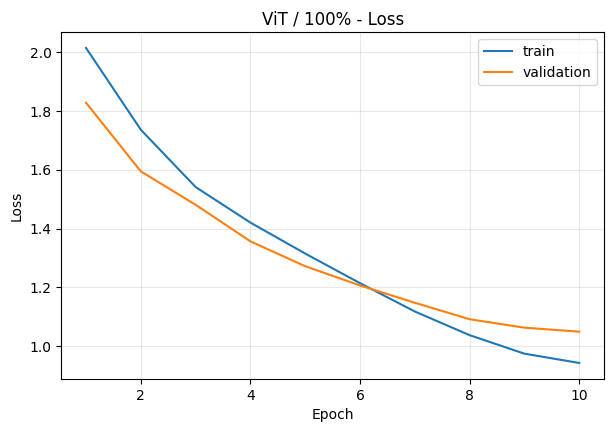

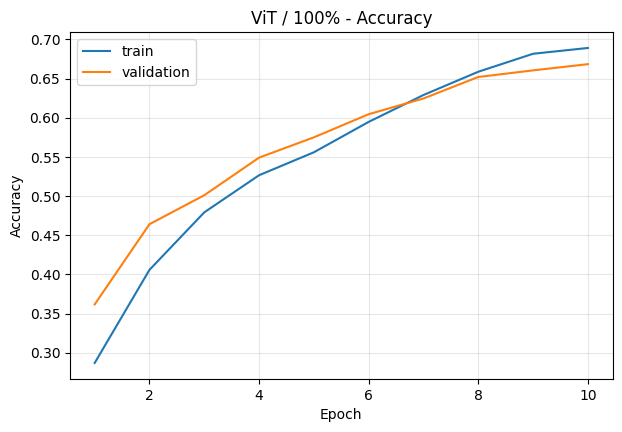

In [19]:
# ── ViT 100% 학습 ───────────────────────────────────────────────
torch.manual_seed(MY_SEED)

vit = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    embed_dim=192,
    depth=12,
    num_heads=3,
    mlp_ratio=4.0,
    dropout=0.1,
)

# ResNet과 동일한 Seed에서 Shuffle을 다시 시작합니다.
vit_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    generator=torch.Generator().manual_seed(MY_SEED),
)

vit, hist_vit_100, summary_vit_100 = train_model(
    model=vit,
    train_loader=vit_train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    model_name="ViT / 100%",
)

plot_history(hist_vit_100, "ViT / 100%")

### Q.4.3 ViT 학습 결과를 확인해봅시다.

1. ViT의 Best Validation Accuracy와 해당 Epoch를 적어주세요.

    A. Best Validation Accuracy는 **0.6684**였고 마지막인 **10번째 epoch**에서 나왔다. 총 학습 시간 7.9분, epoch당 약 47.6초였다. ResNet의 0.8120보다 14.4%p 낮다.

2. 학습은 안정적인 것 같나요? 그렇게 생각한 이유를 설명해주세요.

    A. 오히려 ResNet보다 곡선 자체는 깨끗했다.

    val accuracy가 0.3617 → 0.4641 → 0.5011 → 0.5491 → 0.5750 → 0.6045 → 0.6246 → 0.6521 → 0.6605 → 0.6684로 **10 epoch 동안 단 한 번도 떨어지지 않았다.** val loss도 1.8285에서 1.0487까지 단조 감소했다. ResNet이 epoch 2에서 val acc가 한 번 하락했던 것과 대비된다.

    다만 이건 "안정적으로 잘 학습됐다"보다 **"아직 초반 구간이라 흔들릴 여지조차 없었다"**에 가깝다고 봤다. 마지막 epoch에서도 train acc 0.6891, val acc 0.6684로 둘 사이 간격이 2%p밖에 안 된다. ResNet이 9%p 벌어진 것과 비교하면 ViT는 아직 train set조차 제대로 외우지 못한 상태다. 과적합을 걱정할 단계가 아니라 **학습이 한참 덜 끝난 단계**인 것이다.

    Best Epoch가 10(마지막)이고 마지막 두 epoch에서도 0.6605 → 0.6684로 여전히 오르는 중이었으므로, 20 epoch을 다 돌렸다면 상당히 더 올라갔을 것으로 보인다.

3. ResNet과 ViT 중 어떤 모델이 더 빠르게 높은 Validation Accuracy에 도달했나요? 왜 그런 결과가 나왔다고 생각하나요?

    A. ResNet이 확실히 빨랐다. **ResNet은 1 epoch 만에 val acc 0.4963에 도달했는데, ViT가 그 수준을 넘어서는 데는 3 epoch이 걸렸다.** 최종적으로도 0.8120 대 0.6684로 ResNet이 14.4%p 앞섰다.

    이유는 두 모델이 가진 사전 가정의 차이라고 본다. ResNet의 Convolution에는 "가까운 픽셀끼리 먼저 묶어 보고", "같은 필터를 이미지 전체에 재사용하며", "Local에서 Global로 계층적으로 쌓는다"는 이미지 전용 Inductive Bias가 구조 자체에 박혀 있다. 이건 데이터로부터 배울 필요가 없는, 공짜로 주어진 사전 지식이다. 그래서 첫 epoch부터 바로 쓸 만한 특징을 뽑아낸다.

    반면 ViT는 Patch를 Token 집합으로만 다루고, 어느 Token이 어느 Token과 가까운지조차 Positional Embedding을 통해 처음부터 배워야 한다. 자유도가 큰 만큼 데이터가 충분하면 CNN보다 나은 표현을 찾을 수 있지만, 7,575장 규모에서는 그 자유도를 채울 근거가 부족하다.

    파라미터 수를 보면 이 해석이 더 분명해진다. ViT는 **5,526,346개**로 ResNet의 **11,181,642개**의 절반도 안 되는데 성능은 낮았다. 모델 크기의 문제가 아니라 구조적 가정의 문제다. 한편 epoch당 시간은 ViT가 47.6초로 ResNet의 45.6초보다 길었는데, 파라미터가 절반인데도 더 느린 이유는 197개 Token에 대한 O(N²) Attention을 12개 Block에서 반복하기 때문이다.

---
# 5. ResNet-18 vs ViT — 100% Dataset 기본 비교

두 모델의 첫 번째 학습이 끝났습니다.

이제 동일한 100% Train Dataset에서 얻은 결과를 한 표에 모아봅시다.

여기서 비교할 값은 다음과 같습니다.

- Parameter 수
- Best Validation Accuracy
- Best Epoch
- Epoch당 학습 시간

아직 **Test set은 사용하지 않습니다.**


**여기부터는 코드 빈칸 없습니다!**

In [20]:
# ── 100% Dataset 결과 요약 ─────────────────────────────────────
comparison_100 = pd.DataFrame([
    {
        "Model": "ResNet-18",
        "Parameters": count_parameters(resnet18),
        "Best Val Acc": summary_resnet_100["best_val_acc"],
        "Best Epoch": summary_resnet_100["best_epoch"],
        "Sec / Epoch": summary_resnet_100["sec_per_epoch"],
    },
    {
        "Model": "ViT",
        "Parameters": count_parameters(vit),
        "Best Val Acc": summary_vit_100["best_val_acc"],
        "Best Epoch": summary_vit_100["best_epoch"],
        "Sec / Epoch": summary_vit_100["sec_per_epoch"],
    },
])

comparison_100

,Model,Parameters,Best Val Acc,Best Epoch,Sec / Epoch
0,ResNet-18,11181642,0.812038,10,45.567898
1,ViT,5526346,0.668427,10,47.571413


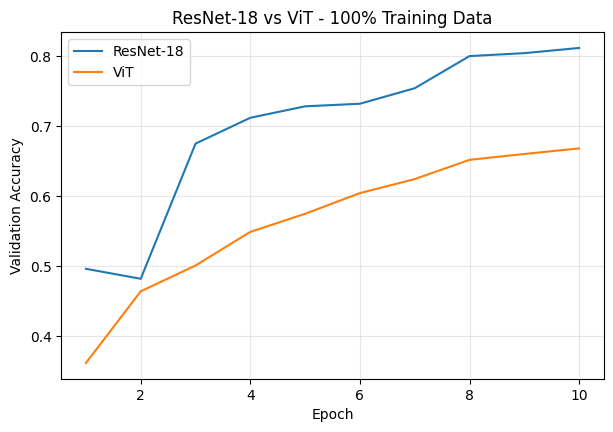

In [21]:
# ── 두 모델의 Validation Accuracy Curve를 한 그래프에서 비교 ───
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(
    epochs,
    hist_resnet_100["val_acc"],
    label="ResNet-18",
)
plt.plot(
    epochs,
    hist_vit_100["val_acc"],
    label="ViT",
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ResNet-18 vs ViT - 100% Training Data")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Q.5 첫 번째 모델 비교

1. 현재 결과만으로 “ResNet이 ViT보다 좋은 모델이다” 혹은 그 반대라고 결론 내리기 어려운 이유를 적어주세요.

    A. 이번 실험은 두 모델의 최고 성능을 겨룬 게 아니라 조건 하나를 고정한 단면만 본 것이기 때문이다.

    우선 Hyperparameter가 ViT에 유리하지 않다. AdamW, lr 3e-4, weight decay 0.05, 20 epoch는 두 모델에 똑같이 적용했지만 ViT는 보통 훨씬 긴 학습과 warmup, 강한 augmentation(RandAugment, Mixup, CutMix)을 전제로 설계된 모델이다. Q.4.3에서 본 것처럼 ViT는 20 epoch에서 아직 수렴조차 하지 않았으므로 "ViT의 성능"이라기보다 "20 epoch까지의 ViT"라고 부르는 게 맞다.

    데이터 규모도 결론을 제한한다. Imagenette 7,575장은 밑바닥부터 학습시키기에 작은 편이고, 이 구간은 원래 CNN에 유리한 영역이다. 6장 실험이 확인하려는 것도 바로 그 점이다.

    마지막으로 시드 하나로 1회 실행한 결과라는 점이 있다. 초기화와 데이터 셔플에 따라 몇 %p 정도는 움직일 수 있어서, 여러 시드로 반복해 평균과 분산을 봐야 차이가 실재하는지 말할 수 있다.

    결국 지금 말할 수 있는 건 "이 데이터 규모와 이 학습 예산에서는 ResNet이 유리했다" 정도다.


2. 이번 비교에서는 두 모델에 같은 Optimizer와 Learning Rate를 사용했습니다. 이것의 **장점**과 **한계**를 각각 하나씩 설명해주세요.

    A. **장점**은 통제 변인이 확보된다는 것이다. Optimizer, Learning Rate, Scheduler, Epoch, Batch Size, 데이터, augmentation까지 전부 같으므로 두 결과의 차이를 만든 요인이 Architecture 하나로 좁혀진다. 만약 각 모델에 따로 튜닝을 했다면 성능 차이가 구조 때문인지 튜닝을 얼마나 잘했는지 때문인지 구분할 수 없게 된다.

    **한계**는 그 공통 조건이 어느 한쪽에 더 잘 맞을 수 있다는 것이다. 이번 설정은 사실상 ResNet 쪽에 가까운 조건이라 ViT는 자기 성능의 일부만 낸 상태로 비교됐다. 그래서 "동일 조건에서의 차이"는 정확히 측정했지만 "각 모델이 낼 수 있는 최선끼리의 차이"는 측정하지 못했다. 공정한 비교와 최선의 비교는 다른 실험이고, 이번 과제는 앞쪽을 택한 것이다.

---
# 6. Training Data Size를 바꾸어 비교해봅시다.

이제 이번 과제의 핵심 비교 실험을 진행합니다.

강의에서는 CNN이 이미지에 대해 다음과 같은 강한 **Inductive Bias**를 갖는다고 배웠습니다.

- Locality: 가까운 Pixel 사이의 관계를 우선적으로 처리
- Weight Sharing: 같은 Convolution Filter를 이미지 전체 위치에 반복 적용
- 계층적으로 Local Feature에서 Global Feature로 확장

반면 기본 ViT는 이러한 이미지 전용 구조적 가정이 상대적으로 약하고, Self-Attention으로 Patch 사이의 관계를 학습합니다.

그렇다면 학습 데이터가 충분하지 않을 때 두 모델은 어떤 차이를 보일까요?

이번에는 같은 Train split에서 **10% / 30% / 100%**만 사용해 두 모델을 각각 처음부터 다시 학습합니다.

> **주의:** 100% 결과는 이미 §3과 §4에서 얻었으므로 다시 학습하지 않고 그대로 재사용합니다.

이번 코드는 총합 20-30분 정도 걸릴겁니다!

### Q.6.1 코드를 실행하기 전에 먼저 예상해봅시다.

아래 질문은 **다음 코드 셀을 실행하기 전에** 답해주세요.

1. Training Data가 `100% → 30% → 10%`로 줄어들 때 ResNet과 ViT 중 어느 모델의 성능 하락폭이 더 클 것이라고 예상하나요?

    A. ViT의 하락폭이 더 클 것이라고 예상한다. 특히 10% 구간에서는 ViT가 거의 무너져서 ResNet과의 격차가 100%일 때보다 더 벌어질 것 같다.

2. 위 예측의 근거를 **CNN의 Inductive Bias**와 연결하여 설명해주세요.

    A. CNN은 이미지에 대한 사전 지식을 구조 안에 이미 갖고 있고, 그 지식은 데이터가 적어도 사라지지 않기 때문이다.

    Convolution은 Locality(가까운 픽셀끼리 먼저 본다), Weight Sharing(같은 필터를 모든 위치에 재사용한다), Translation Equivariance(대상이 옮겨가면 출력도 같이 옮겨간다)를 가정으로 깔고 있다. 이 가정들은 자연 이미지에서 대체로 참이므로, CNN은 "엣지와 질감을 먼저 잡고 이를 조합해 물체를 만든다"는 방향을 데이터로부터 배울 필요 없이 처음부터 부여받는다. Weight Sharing은 같은 필터가 이미지의 모든 위치에서 학습 신호를 받는다는 뜻이기도 해서, 이미지 한 장에서 뽑아내는 정보량 자체가 많다.

    ViT에는 이런 가정이 거의 없다. Patch 사이의 공간 관계조차 Positional Embedding을 통해 데이터로부터 배워야 하고, Self-Attention은 어떤 Token 쌍이든 동등하게 연결할 수 있어 자유도가 훨씬 크다. 자유도가 크다는 건 그만큼 많은 예시가 있어야 올바른 규칙을 좁혀낼 수 있다는 뜻이다. 데이터가 줄면 ViT는 이미지의 기본 성질부터 다시 배워야 하는 반면 CNN은 그 부분을 이미 갖고 있으므로, 같은 감소량이라도 ViT가 더 크게 타격을 받을 것이다.

    ViT 논문의 결론도 같은 맥락이다. 데이터가 작을 때는 CNN이 앞서지만 규모가 커지면 역전되는데, 이는 Inductive Bias가 데이터가 적을 때는 도움이 되고 충분할 때는 오히려 제약이 되기 때문이다.

In [22]:
# ── 특정 비율의 Train Data를 Stratified Sampling하는 함수 ──────
def make_fraction_indices(base_indices, all_targets, fraction, seed):
    """
    기존 Train Index에서 지정한 비율만큼 샘플링합니다.

    stratify를 사용하여 10%나 30%만 뽑더라도
    10개 클래스의 비율이 최대한 유지되도록 합니다.
    """
    base_indices = np.asarray(base_indices)

    if fraction >= 1.0:
        return base_indices.copy()

    base_targets = np.asarray(all_targets)[base_indices]

    sampled_indices, _ = train_test_split(
        base_indices,
        train_size=fraction,
        random_state=seed,
        stratify=base_targets,
    )

    return np.asarray(sampled_indices)


def make_train_loader(indices, seed):
    """주어진 Train Index로 새로운 DataLoader를 만듭니다."""
    dataset = Subset(
        train_aug_dataset,
        indices,
    )

    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        generator=generator,
    )


# 실제 각 비율에서 몇 장이 사용되는지 먼저 확인합니다.
fractions = [0.10, 0.30, 1.00]

for frac in fractions:
    idx = make_fraction_indices(
        train_indices,
        train_targets,
        fraction=frac,
        seed=MY_SEED,
    )
    print(f"{frac:>4.0%} -> {len(idx):5d} training images")

 10% ->   757 training images
 30% ->  2272 training images
100% ->  7575 training images


In [23]:
# ── Data Size Experiment ────────────────────────────────────────
# 100% 결과는 이미 학습했으므로 재사용하고,
# 10% / 30% 조건만 새롭게 학습합니다.

data_size_results = []

# 먼저 100% 결과를 기록합니다.
data_size_results.extend([
    {
        "Model": "ResNet-18",
        "Fraction": 1.00,
        "Train Images": len(train_indices),
        "Best Val Acc": summary_resnet_100["best_val_acc"],
        "Best Epoch": summary_resnet_100["best_epoch"],
        "Sec / Epoch": summary_resnet_100["sec_per_epoch"],
    },
    {
        "Model": "ViT",
        "Fraction": 1.00,
        "Train Images": len(train_indices),
        "Best Val Acc": summary_vit_100["best_val_acc"],
        "Best Epoch": summary_vit_100["best_epoch"],
        "Sec / Epoch": summary_vit_100["sec_per_epoch"],
    },
])

# ── 10% / 30% 조건을 차례대로 학습 ─────────────────────────────
for fraction in [0.10, 0.30]:

    subset_indices = make_fraction_indices(
        train_indices,
        train_targets,
        fraction=fraction,
        seed=MY_SEED,
    )

    print("\n" + "=" * 80)
    print(
        f"Training Data = {fraction:.0%} "
        f"({len(subset_indices)} images)"
    )
    print("=" * 80)

    # ── ResNet-18 ───────────────────────────────────────────────
    # 매 실험마다 반드시 새 모델을 만들어 Random Initialization부터 다시 시작합니다.
    torch.manual_seed(MY_SEED)

    resnet_tmp = ResNet18(
        num_classes=NUM_CLASSES
    )

    fraction_loader_resnet = make_train_loader(
        subset_indices,
        seed=MY_SEED,
    )

    resnet_tmp, hist_resnet_tmp, summary_resnet_tmp = train_model(
        model=resnet_tmp,
        train_loader=fraction_loader_resnet,
        val_loader=val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        model_name=f"ResNet-18 / {fraction:.0%}",
    )

    data_size_results.append({
        "Model": "ResNet-18",
        "Fraction": fraction,
        "Train Images": len(subset_indices),
        "Best Val Acc": summary_resnet_tmp["best_val_acc"],
        "Best Epoch": summary_resnet_tmp["best_epoch"],
        "Sec / Epoch": summary_resnet_tmp["sec_per_epoch"],
    })

    del resnet_tmp
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    # ── ViT ─────────────────────────────────────────────────────
    torch.manual_seed(MY_SEED)

    vit_tmp = VisionTransformer(
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_classes=NUM_CLASSES,
        embed_dim=192,
        depth=12,
        num_heads=3,
        mlp_ratio=4.0,
        dropout=0.1,
    )

    fraction_loader_vit = make_train_loader(
        subset_indices,
        seed=MY_SEED,
    )

    vit_tmp, hist_vit_tmp, summary_vit_tmp = train_model(
        model=vit_tmp,
        train_loader=fraction_loader_vit,
        val_loader=val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        model_name=f"ViT / {fraction:.0%}",
    )

    data_size_results.append({
        "Model": "ViT",
        "Fraction": fraction,
        "Train Images": len(subset_indices),
        "Best Val Acc": summary_vit_tmp["best_val_acc"],
        "Best Epoch": summary_vit_tmp["best_epoch"],
        "Sec / Epoch": summary_vit_tmp["sec_per_epoch"],
    })

    del vit_tmp
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


Training Data = 10% (757 images)
[ResNet-18 / 10%] Epoch 01/10 | train loss 2.1052 acc 0.2417 | val loss 2.8621 acc 0.1536 | lr 3.00e-04
[ResNet-18 / 10%] Epoch 02/10 | train loss 1.6899 acc 0.4188 | val loss 3.4761 acc 0.2033 | lr 2.93e-04
[ResNet-18 / 10%] Epoch 03/10 | train loss 1.5093 acc 0.4584 | val loss 2.6037 acc 0.2830 | lr 2.71e-04
[ResNet-18 / 10%] Epoch 04/10 | train loss 1.3742 acc 0.5284 | val loss 1.9580 acc 0.3838 | lr 2.38e-04
[ResNet-18 / 10%] Epoch 05/10 | train loss 1.1356 acc 0.6248 | val loss 1.5536 acc 0.5005 | lr 1.96e-04
[ResNet-18 / 10%] Epoch 06/10 | train loss 0.9381 acc 0.6684 | val loss 1.4711 acc 0.5380 | lr 1.50e-04
[ResNet-18 / 10%] Epoch 07/10 | train loss 0.8716 acc 0.7252 | val loss 1.3528 acc 0.5702 | lr 1.04e-04
[ResNet-18 / 10%] Epoch 08/10 | train loss 0.7104 acc 0.7635 | val loss 1.3143 acc 0.5787 | lr 6.18e-05
[ResNet-18 / 10%] Epoch 09/10 | train loss 0.6233 acc 0.8151 | val loss 1.2877 acc 0.6051 | lr 2.86e-05
[ResNet-18 / 10%] Epoch 10/10 

In [24]:
# ── Data Size Experiment 결과표 ─────────────────────────────────
data_size_df = pd.DataFrame(data_size_results)

data_size_df = data_size_df.sort_values(
    ["Model", "Fraction"]
).reset_index(drop=True)

data_size_df

,Model,Fraction,Train Images,Best Val Acc,Best Epoch,Sec / Epoch
0,ResNet-18,0.1,757,0.609293,10,12.289129
1,ResNet-18,0.3,2272,0.704329,10,19.437607
2,ResNet-18,1.0,7575,0.812038,10,45.567898
3,ViT,0.1,757,0.355861,10,12.880012
4,ViT,0.3,2272,0.504224,10,20.237125
5,ViT,1.0,7575,0.668427,10,47.571413


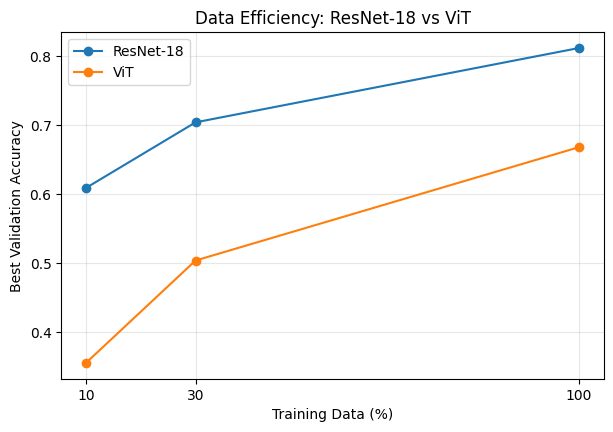

In [25]:
# ── Training Data 비율에 따른 Validation Accuracy 변화 ─────────
plt.figure(figsize=(7, 4.5))

for model_name in ["ResNet-18", "ViT"]:
    temp = data_size_df[
        data_size_df["Model"] == model_name
    ].sort_values("Fraction")

    plt.plot(
        temp["Fraction"] * 100,
        temp["Best Val Acc"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Training Data (%)")
plt.ylabel("Best Validation Accuracy")
plt.title("Data Efficiency: ResNet-18 vs ViT")
plt.xticks([10, 30, 100])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [26]:
# ── 10% -> 100%에서 Accuracy가 얼마나 변했는지 계산 ────────────
pivot_acc = data_size_df.pivot(
    index="Fraction",
    columns="Model",
    values="Best Val Acc",
).sort_index()

print(pivot_acc)

print("\n[Accuracy change: 10% -> 100%]")
for model_name in ["ResNet-18", "ViT"]:
    acc_10 = pivot_acc.loc[0.10, model_name]
    acc_100 = pivot_acc.loc[1.00, model_name]
    change = acc_100 - acc_10

    print(
        f"{model_name:10s}: "
        f"{acc_10:.4f} -> {acc_100:.4f} "
        f"(+{change:.4f}, {change*100:.2f}%p)"
    )

Model     ResNet-18       ViT
Fraction                     
0.1        0.609293  0.355861
0.3        0.704329  0.504224
1.0        0.812038  0.668427

[Accuracy change: 10% -> 100%]
ResNet-18 : 0.6093 -> 0.8120 (+0.2027, 20.27%p)
ViT       : 0.3559 -> 0.6684 (+0.3126, 31.26%p)


### Q.6.2 실제 결과를 바탕으로 판단해봅시다.

1. 10%, 30%, 100%에서 ResNet-18과 ViT의 Best Validation Accuracy를 모두 적어주세요.

    A. 아래 표와 같다.

    | Training Data | 이미지 수 | ResNet-18 | ViT | 격차 |
    |---|---|---|---|---|
    | 10% | 757장 | 0.6093 | 0.3559 | 25.3%p |
    | 30% | 2,272장 | 0.7043 | 0.5042 | 20.0%p |
    | 100% | 7,575장 | 0.8120 | 0.6684 | 14.4%p |

    세 구간 모두 ResNet이 앞섰지만, **데이터가 늘어날수록 격차가 계속 좁혀졌다**(25.3 → 20.0 → 14.4%p).

2. 각 모델에서 `10% → 100%`로 데이터가 증가했을 때 Accuracy가 몇 %p 증가했나요?

    A. 노트북 출력 기준으로

    - ResNet-18 : 0.6093 → 0.8120 (**+20.27%p**)
    - ViT : 0.3559 → 0.6684 (**+31.26%p**)

    ViT의 증가폭이 ResNet보다 **11%p 가까이 컸다.** 같은 양의 데이터가 추가됐을 때 ViT가 훨씬 많이 가져간 것이다.

3. Q.6.1에서 작성한 본인의 사전 예측과 실제 결과가 일치했나요?

    A. 일치했다. 두 가지 기준 모두에서 맞았다.

    **절대 %p 기준.** 10% → 100%에서 ViT는 31.26%p 올랐고 ResNet은 20.27%p 올랐다. 뒤집어 말하면 100%에서 10%로 데이터를 줄였을 때 ViT가 31.26%p를 잃는 동안 ResNet은 20.27%p만 잃었다는 뜻이다. 예측한 대로 ViT의 하락폭이 더 컸다.

    **상대 유지율 기준.** 각 모델이 자기 100% 성능의 몇 %를 유지했는지로 보면 ResNet은 0.6093/0.8120 = **75.0%**를 지킨 반면 ViT는 0.3559/0.6684 = **53.2%**만 지켰다. ViT는 데이터를 10분의 1로 줄이자 성능의 거의 절반을 잃은 셈이다.

    처음에는 ViT의 천장이 낮아서 절대 %p로는 반대 결과가 나올 수도 있다고 생각했는데, 실제로는 두 기준이 같은 방향을 가리켰다. ViT가 10%에서 0.3559까지 떨어진 게 결정적이었다. 10개 클래스 문제의 random guess가 0.1이니 그보다는 높지만, 세 장 중 두 장을 틀리는 수준이라 실용적이라고 보기 어렵다.

    예상하지 못했던 건 **격차가 데이터가 늘수록 좁혀졌다**는 점이다(25.3 → 20.0 → 14.4%p). 예측할 때는 ViT가 데이터에 민감하다는 것까지만 생각했는데, 그 민감함이 반대 방향으로도 작동해서 데이터가 늘면 ViT가 더 빠르게 따라붙는다는 것까지는 미처 연결하지 못했다. ViT 논문이 말한 "데이터가 충분해지면 역전된다"는 주장의 앞부분을 이 작은 실험에서도 볼 수 있었던 셈이다. 다만 100%에서도 여전히 14.4%p 뒤져 있으므로 역전 지점은 7,575장보다 훨씬 뒤에 있다.

4. ResNet은 Convolution을 통해 Local Feature를 계층적으로 학습하고, ViT는 Patch Token 사이의 Self-Attention을 사용합니다. 이러한 구조 차이가 학습 데이터의 양에 따른 성능 변화와 어떤 관계가 있다고 생각하나요?

    A. 구조가 미리 갖고 있는 가정의 양과, 그 가정을 데이터로 대신 채워야 하는 양 사이의 교환 관계로 설명된다.

    ResNet은 "가까운 픽셀이 더 관련 있다", "같은 패턴은 위치가 달라도 같은 패턴이다" 같은 이미지의 성질을 구조에 못 박아 두었다. 3×3 Conv는 애초에 이웃한 9개 픽셀만 보고, 같은 필터가 모든 위치를 훑는다. 이 제약은 모델이 탐색할 수 있는 함수의 범위를 크게 좁혀 준다. 데이터가 757장뿐인 상황에서도 ResNet이 0.6093을 낸 것은, 좁혀진 탐색 공간 안에서 그럴듯한 해를 찾기가 쉬웠기 때문이다. Weight Sharing 덕분에 이미지 한 장에서 필터가 받는 학습 신호의 양이 많다는 점도 크다.

    ViT는 그 제약이 거의 없다. Self-Attention은 어떤 Patch 쌍이든 동등하게 연결할 수 있고 위치 관계조차 Positional Embedding으로 배워야 한다. 탐색 공간이 훨씬 넓다는 뜻이고, 넓은 공간에서 옳은 해를 찾으려면 그만큼 많은 예시가 필요하다. 757장에서 0.3559에 그친 것은 이미지의 기본 성질을 배울 근거 자체가 부족했기 때문으로 보인다.

    그런데 이 실험이 보여 준 건 **같은 성질이 양방향으로 작동한다**는 점이다. 데이터가 적을 때 ViT가 더 크게 무너지는 이유와, 데이터가 늘 때 ViT가 더 빠르게 좋아지는 이유가 같다. 제약이 없으니 데이터가 없으면 아무것도 못 하지만, 데이터가 주어지면 그만큼을 온전히 흡수한다. ResNet은 반대로 제약 덕분에 적은 데이터에서 버티지만, 데이터가 늘어도 그 제약의 범위 안에서만 좋아지므로 증가폭이 작다(+20.27%p 대 +31.26%p).

    이 교환이 계속되면 어느 지점에서 역전이 일어날 것이다. 격차가 25.3 → 20.0 → 14.4%p로 줄고 있으므로 방향은 그쪽인데, 다만 이 구간에서는 아직 CNN 쪽이 유리한 영역이었다. CNN의 가정은 대체로 옳지만 항상 옳지는 않아서, 멀리 떨어진 영역 사이의 관계나 이미지 전역의 맥락 같은 것은 Convolution이 표현하기 어렵다. 데이터가 그 가정 없이도 올바른 규칙을 찾아낼 만큼 많아지는 순간부터 ViT의 자유도가 강점이 된다.

---
# 7. 마지막으로 Test Set을 확인해봅시다.

지금까지 모델 비교와 Data Size 실험은 Validation Set을 기준으로 진행했습니다.

이제 모든 비교가 끝났으므로, **100% Dataset에서 학습한 ResNet-18과 ViT의 Best Weight**를 Test Set에서 평가해봅시다.

Test Set은 최종 성적표에 해당합니다.  
만약 Test Accuracy를 반복해서 확인하면서 Hyperparameter를 바꾼다면 Test Set도 사실상 Validation Set처럼 사용하게 되므로, 최종 일반화 성능을 정직하게 측정하기 어려워집니다.

In [27]:
# ── 최종 Test Evaluation ────────────────────────────────────────
resnet_test_loss, resnet_test_acc = evaluate(
    resnet18,
    test_loader,
    DEVICE,
)

vit_test_loss, vit_test_acc = evaluate(
    vit,
    test_loader,
    DEVICE,
)

final_test_df = pd.DataFrame([
    {
        "Model": "ResNet-18",
        "Best Val Acc": summary_resnet_100["best_val_acc"],
        "Test Loss": resnet_test_loss,
        "Test Acc": resnet_test_acc,
    },
    {
        "Model": "ViT",
        "Best Val Acc": summary_vit_100["best_val_acc"],
        "Test Loss": vit_test_loss,
        "Test Acc": vit_test_acc,
    },
])

final_test_df

,Model,Best Val Acc,Test Loss,Test Acc
0,ResNet-18,0.812038,0.558953,0.822930
1,ViT,0.668427,1.076357,0.655541


In [28]:
# ── Class별 Test Accuracy도 함께 확인 ───────────────────────────
@torch.no_grad()
def per_class_accuracy(model, loader, device, num_classes):
    """각 Class별 정답 수 / 전체 수를 계산합니다."""
    model.eval()

    correct = np.zeros(num_classes, dtype=np.int64)
    total = np.zeros(num_classes, dtype=np.int64)

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        for c in range(num_classes):
            mask = labels == c
            total[c] += mask.sum().item()
            correct[c] += ((preds == labels) & mask).sum().item()

    return correct / total


resnet_class_acc = per_class_accuracy(
    resnet18, test_loader, DEVICE, NUM_CLASSES
)

vit_class_acc = per_class_accuracy(
    vit, test_loader, DEVICE, NUM_CLASSES
)

class_result_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "ResNet-18": resnet_class_acc,
    "ViT": vit_class_acc,
})

class_result_df

,Class,ResNet-18,ViT
0,tench,0.909561,0.803618
1,English springer,0.896203,0.779747
2,cassette player,0.873950,0.700280
3,chain saw,0.668394,0.471503
4,church,0.836186,0.603912
5,French horn,0.812183,0.626904
6,garbage truck,0.807198,0.647815
7,gas pump,0.749403,0.572792
8,golf ball,0.827068,0.604010
9,parachute,0.856410,0.756410


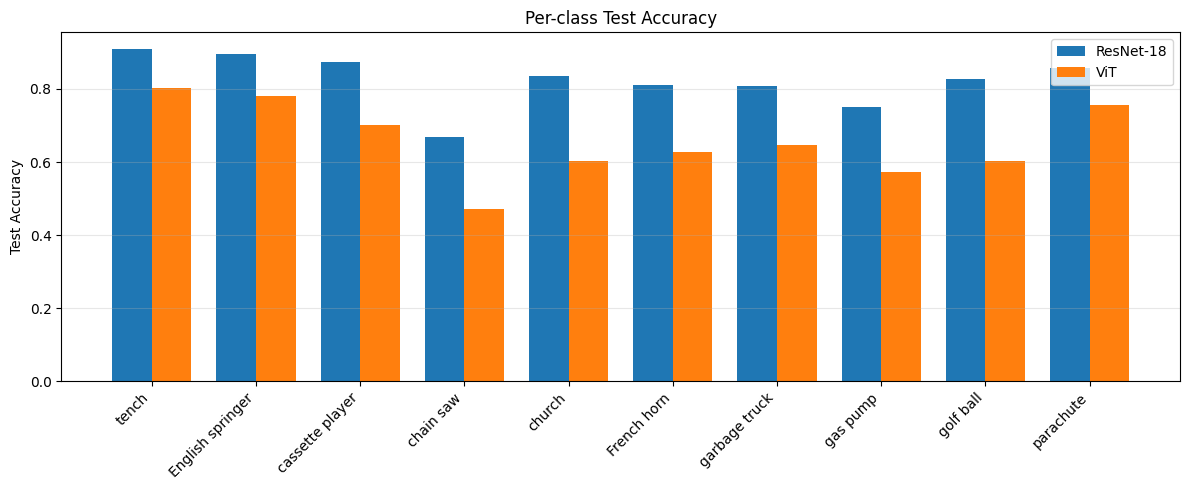

In [29]:
# ── Class별 성능 비교 그래프 ────────────────────────────────────
x = np.arange(NUM_CLASSES)
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(
    x - width / 2,
    resnet_class_acc,
    width,
    label="ResNet-18",
)
plt.bar(
    x + width / 2,
    vit_class_acc,
    width,
    label="ViT",
)

plt.xticks(
    x,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)
plt.ylabel("Test Accuracy")
plt.title("Per-class Test Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Q.7 최종 서술형

1. 이번 실험에서 관찰한 ResNet과 ViT의 학습 특성 차이를 Data Size Experiment의 실제 결과를 근거로 설명해주세요.

    A. 네 가지가 뚜렷하게 갈렸다.

    **데이터 효율.** 10%(757장)에서 ResNet 0.6093, ViT 0.3559로 25.3%p나 벌어졌다. 자기 100% 성능 대비 유지율로 보면 ResNet 75.0%, ViT 53.2%로 ViT가 절반 가까이를 잃었다. 데이터가 적을 때 Inductive Bias가 실제로 방어막 역할을 한다는 것이 숫자로 확인됐다.

    **데이터 증가에 대한 반응.** 반대로 10% → 100%에서 ViT는 +31.26%p, ResNet은 +20.27%p 올라 ViT가 훨씬 가파르게 좋아졌다. 그래서 격차가 25.3 → 20.0 → 14.4%p로 계속 좁혀졌다. 제약이 없다는 성질이 적은 데이터에서는 약점으로, 많은 데이터에서는 강점으로 양방향으로 작동한다는 뜻이다.

    **수렴 상태.** 두 모델 모두 Best Epoch가 10(마지막)이었지만 의미가 달랐다. ResNet은 train acc 0.9063 / val acc 0.8120으로 9%p 벌어져 과적합 쪽으로 기울고 있었던 반면, ViT는 0.6891 / 0.6684로 2%p밖에 차이가 안 나 train set조차 아직 못 외운 상태였다. ViT는 학습이 덜 끝난 것이다.

    **파라미터·속도 효율.** ViT는 5,526,346개로 ResNet(11,181,642개)의 절반도 안 되는 파라미터를 쓰면서 성능은 14.4%p 낮았고, epoch당 시간은 47.6초로 ResNet의 45.6초보다 오히려 길었다. 197개 Token에 대한 O(N²) Attention을 12개 Block에서 반복하기 때문이다.

    Test set에서도 같은 순서가 유지됐다. ResNet **0.8229**, ViT **0.6555**로 validation과 거의 같은 값이 나와, 이 차이가 validation에 과적합된 결과가 아니라는 것도 확인됐다. 클래스별로 보면 두 모델 모두 chain saw에서 가장 낮았는데(ResNet 0.6684, ViT 0.4715) 배경이 복잡하고 형태 변화가 큰 클래스라 그런 것으로 보인다.

    종합하면, 이 구간에서 차이를 만든 것은 모델의 크기가 아니라 **구조가 미리 갖고 있는 가정의 양**이었다.

2. Imagenette보다 훨씬 큰 Dataset에서 충분히 학습한다면 두 모델의 격차가 어떻게 변할 것으로 예상하나요?

    A. 계속 좁혀지다가 결국 뒤집힐 것으로 예상한다. 이번 실험이 그 추세의 앞부분을 이미 보여 줬다고 본다.

    근거는 격차의 변화 방향이다. 10%에서 25.3%p였던 차이가 30%에서 20.0%p, 100%에서 14.4%p로 데이터가 늘 때마다 꾸준히 줄었다. 10% → 100%의 증가폭도 ViT가 +31.26%p로 ResNet(+20.27%p)보다 1.5배 컸다. 이 기울기가 유지된다면 어느 지점에서 만나게 된다.

    ViT가 아직 여유를 남겨 뒀다는 점도 근거다. 10 epoch 시점에 ViT는 train acc 0.6891로 train set조차 못 외운 상태였고 val accuracy도 마지막까지 오르는 중이었다. 반면 ResNet은 train acc 0.9063으로 이미 과적합 쪽에 들어섰다. ResNet은 천장에 가까워지고 있고 ViT는 아직 올라갈 데가 남아 있다.

    이론적으로도 그렇다. 데이터가 충분해지면 CNN의 Inductive Bias는 도움에서 제약으로 성격이 바뀐다. "가까운 픽셀이 더 관련 있다"는 가정은 대체로 맞지만 예외가 있고, 데이터가 많으면 모델이 그 예외까지 직접 배울 수 있게 되는데 Convolution은 구조상 그걸 표현하기 어렵다. ViT 논문에서 ImageNet-1k에서는 ResNet에 밀리다가 ImageNet-21k에서 비슷해지고 JFT-300M에서 역전되는 결과가 정확히 이 그림이다.

    다만 조건이 붙는다. 단순히 이미지 수만 늘린다고 되는 게 아니라 학습 epoch, warmup, 강한 augmentation 같은 ViT 쪽 학습 레시피가 함께 갖춰져야 한다. 이번 실험만 해도 10 epoch이라는 예산이 ViT에게 불리했다. DeiT가 distillation과 augmentation만으로 ImageNet-1k에서도 ViT를 경쟁력 있게 만든 사례를 보면, 데이터 양과 학습 방법 중 어느 하나만으로는 부족하고 둘이 같이 가야 하는 것 같다.

---

## Q.8 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로):

  세 군데에 썼고, 전부 내가 먼저 답을 써 놓고 맞는지 대조하는 용도였다.

  (1) `BasicBlock`에서 Shortcut에 1×1 Conv를 걸어야 하는 조건을 내가 `stride != 1 or in_channels != out_channels`로 적어 놓고 이게 맞는지 물어봤다. (2) `nn.MultiheadAttention`에 Pre-Norm을 적용할 때 Query/Key/Value에 무엇을 넣어야 하는지, `batch_first=True`가 정확히 어떤 Shape를 기대하는지 확인했다. (3) ResNet 파라미터가 11,181,642개로 나왔는데 이 값이 표준 ResNet-18과 맞는 수치인지 검산했다.

  코드는 AI 답을 그대로 옮기지 않고 `print(x.shape)`로 중간 Shape를 찍어 보거나 dummy forward를 돌려 확인한 뒤에만 반영했다.

- **AI가 이 실험에는 틀린 답을 준 사례** —
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요:

  **사례 1. Shortcut 조건을 `in_channels != out_channels`만으로 충분하다고 답함.**

  내가 쓴 `stride != 1 or in_channels != out_channels`를 보여 주며 앞의 조건이 필요한지 물었더니, 채널이 바뀔 때만 Projection이 필요하므로 `in_channels != out_channels`만 있으면 된다고 답했다. 실제로 이 노트북의 `layer2`~`layer4` 첫 Block은 stride가 2로 바뀔 때 채널도 같이 바뀌기 때문에 그 조건만으로도 우연히 동작하고, 학습을 돌려도 에러가 안 난다.

  이상하다고 느낀 건 stride와 채널이 항상 같이 바뀌리라는 보장이 없어서였다. 확인하려고 `BasicBlock(64, 64, stride=2)`를 직접 만들어 `torch.randn(2, 64, 56, 56)`을 넣어 봤더니 `RuntimeError: The size of tensor a (28) must match the size of tensor b (56)`가 났다. Main Path는 stride=2라 28×28이 되는데 Shortcut은 Identity라 56×56 그대로여서 Addition이 안 되는 것이었다. 채널이 같아도 공간 크기가 다르면 더할 수 없으니 `stride != 1` 조건이 반드시 필요하다. 지금 구조에서는 증상이 안 나타나는 종류의 오답이라 더 위험했다.

  **사례 2. Pre-Norm의 Residual을 정규화된 값에 더하라고 답함.**

  Encoder Block의 첫 Residual을 `x = norm_x + attn_out`으로 쓰면 된다고 답했다. Shape가 전부 (B, 197, 192)로 같아서 실행해도 에러가 전혀 나지 않는다.

  그런데 노트북 위쪽 설명에 적힌 식이 `x = x + MSA(LN(x))`였다. LayerNorm은 Attention에 들어가는 입력에만 적용하고, 더하는 쪽은 정규화 **이전의** `x`여야 한다. `norm_x`를 더해 버리면 Residual 경로에도 LayerNorm이 끼어들어 스킵 경로가 항등 사상이 아니게 되고, Pre-Norm이 주는 이점(스킵 경로를 따라 gradient가 감쇠 없이 흐르는 것)이 사라진다. 사실상 Post-Norm에 가까운 형태가 되어 깊은 층에서 학습이 불안정해진다.

  두 사례 모두 **에러가 안 나는 오답**이었다는 게 공통점이다. 첫 번째는 이 구조에서 우연히 가려졌고 두 번째는 Shape가 맞아 넘어갔다. 실행이 된다고 맞는 게 아니라는 걸 확인한 셈이다.

- **실제 대화 내역** 붙여넣기:

```
나: ResNet BasicBlock에서 shortcut에 1x1 conv 거는 조건을
    stride != 1 or in_channels != out_channels 로 썼는데, 앞의 stride 조건도 필요해?

AI: 채널 수가 달라질 때만 projection이 필요하므로
    in_channels != out_channels 조건만으로 충분합니다.
    stride는 conv3x3에서 이미 처리되므로 shortcut에서 고려하지 않아도 됩니다.

나: 그러면 stride=2인데 in_channels == out_channels인 블록은 어떻게 돼?
    BasicBlock(64, 64, stride=2)에 (2,64,56,56) 넣어봤더니
    RuntimeError: The size of tensor a (28) must match the size of tensor b (56) 나는데.

AI: 맞습니다. stride=2이면 main path의 spatial size가 절반이 되므로
    identity shortcut과 shape가 달라져 addition이 불가능합니다.
    stride != 1 조건이 반드시 필요합니다. 앞선 답변이 틀렸습니다.

---

나: ViT encoder block에서 pre-norm 쓸 때 첫 residual 어떻게 써?

AI: norm_x = self.norm1(x) 로 정규화한 뒤
    x = norm_x + attn_out 으로 더하시면 됩니다.

나: 근데 pre-norm 식이 x = x + MSA(LN(x)) 아니야?
    norm_x를 더하면 residual 경로에도 LayerNorm이 들어가는 거잖아.

AI: 정확합니다. residual은 정규화 이전의 x에 더해야 하며
    x = x + attn_out 이 맞습니다. norm_x를 더하면 skip path가
    항등 사상이 아니게 되어 pre-norm의 이점이 사라집니다.
```

  두 번째 사례가 특히 신경 쓰였다. Shape가 맞아서 실행도 되고 학습도 돌아가니, 노트북 설명에 적힌 식과 한 줄씩 대조해 보지 않았다면 끝까지 몰랐을 것이다.

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은?

  AI는 물어본 것마다 자신 있는 어조로 답했지만 "지금 이 코드는 에러가 안 날 뿐 틀렸다"는 판단은 해주지 못했고, 조건을 일부러 깨뜨리는 입력을 만들어 직접 돌려 보거나 노트북에 적힌 수식과 한 줄씩 대조해 오답을 잡아낸 건 결국 내가 해야 하는 일이었다.

___
#5주차 과제는 이상입니다. 모두 수고하셨습니다 :)